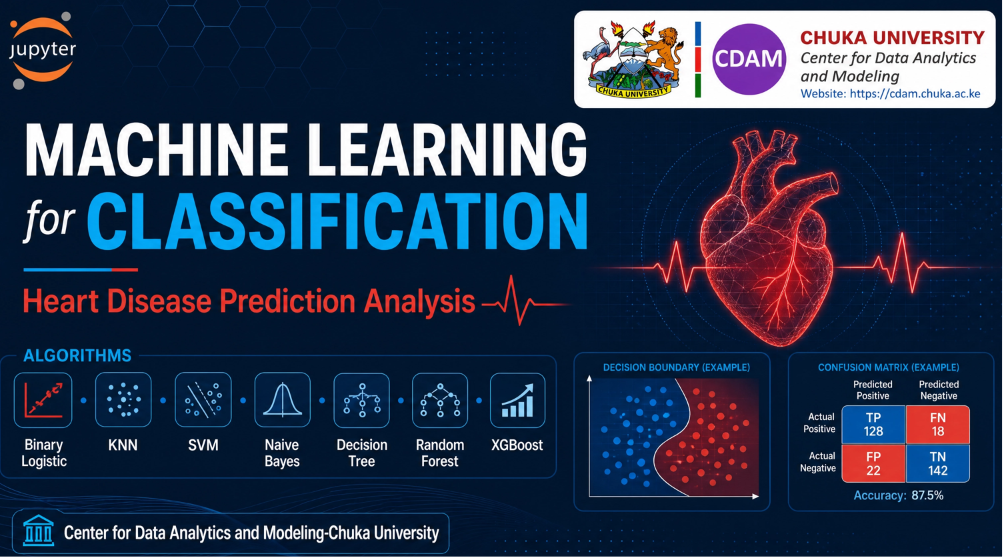

<div style="text-align: center; font-weight: bold; font-size: 22px; color: #1a1a1a;">
  <div style="color: #351C75; font-size: 30px;">FACILITATOR:</div>
  <div style="color: #000000; font-size: 25px;">VICTOR WANDERA LUMUMBA</div>
  <div style="color: #3D85C6; font-size: 25px;">Chuka University, Kenya</div>
  <br>
  <div style="color: #6AA84F; font-size: 18px;">Date:</div>
  <div style="color: #351C75; font-size: 18px;">June 9th, 2026</div>
</div>

## **MACHINE LEARNING**

Machine Learning (ML) is a branch of Artificial Intelligence that enables computers to learn patterns from data and make predictions or decisions without being explicitly programmed. Instead of following fixed rules, machine learning algorithms improve their performance as they are exposed to more data.

### **Why Machine Learning?**

Machine learning is used to analyze large amounts of data, uncover hidden patterns, make predictions, automate decision-making, and improve accuracy in solving real-world problems.

### **Branches of Machine Learning**

**Supervised Learning** uses labeled data, where the correct output is already known. It is mainly used for **classification** (predicting categories such as spam or not spam) and **regression** (predicting continuous values such as house prices).

**Unsupervised Learning** uses unlabeled data to discover hidden structures or patterns. It is commonly applied in clustering, customer segmentation, and association rule mining.

**Semi-Supervised Learning** combines a small amount of labeled data with a large amount of unlabeled data to improve model performance, especially when labeling data is expensive.

**Reinforcement Learning** enables an agent to learn by interacting with its environment and receiving rewards or penalties. It is widely used in robotics, autonomous vehicles, and game-playing systems.

### **Types of Machine Learning Problems**

Machine learning problems are generally classified into **classification**, **regression**, **clustering**, and **anomaly detection**. Classification predicts categories, regression predicts numerical values, clustering groups similar observations, while anomaly detection identifies unusual or suspicious patterns.

### **Applications of Machine Learning**

Machine learning has applications across many fields. In healthcare, it supports disease diagnosis and medical image analysis. In finance, it is used for fraud detection and credit scoring. Businesses use it for customer segmentation, sales forecasting, and recommendation systems. Other applications include agriculture, education, transportation, manufacturing, cybersecurity, and environmental monitoring.

### **Advantages**

Machine learning can process large datasets efficiently, identify complex patterns, improve prediction accuracy, automate repetitive tasks, and support data-driven decision-making.

### **Challenges**

Despite its benefits, machine learning requires high-quality data, significant computational resources, and careful model selection. Poor data quality, overfitting, and biased datasets can reduce model performance.

### **Summary**

Machine learning is a powerful field of Artificial Intelligence that allows computers to learn from data and improve their predictions over time. Its four major branches—supervised, unsupervised, semi-supervised, and reinforcement learning—provide solutions to a wide range of prediction, classification, and pattern recognition problems across numerous industries.


### **STAGE 1: PROBLEM FORMULATION**
Clinical Objective: Predict presence of Atherosclerotic Heart Disease (AHD) to enable 
early intervention and risk stratification.

Target Variable: 'AHD' (Binary: 0 = No Disease, 1 = Disease Present)

Real-World Implications:
- False Negatives: Missed cardiac risk → delayed treatment, potential acute events (MI, stroke).
  HIGH clinical cost. Recall/Sensitivity is prioritized.
- False Positives: Unnecessary angiography/stress tests → patient anxiety, healthcare costs.
  MODERATE clinical cost. Precision balances this.
- Calibration: Clinicians require well-calibrated probabilities to make shared decisions.

Hypotheses:
1. XGBoost will outperform RF in discrimination (ROC-AUC) due to gradient optimization 
   and regularization, but may require careful calibration for probability outputs.
> Key predictors: Age, MaxHR, Oldpeak, ChestPain type, and Ca/Thal values.
> Dynamic class weighting + stratified CV will mitigate bias toward the majority class.

### **STAGE 2: LIBRARIES, DATA IMPORTATION & EXPLORATORY INSPECTION**
This code loads the Heart.csv dataset into a pandas DataFrame called df and automatically treats values such as "NA", "?", and empty cells ("") as missing values (NaN). The df.head() command then displays the first five rows of the dataset so you can quickly inspect its structure and contents.

### **Load the Required Libraries**

In [1]:
#!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
from sklearn.inspection import PartialDependenceDisplay
from scipy.stats import chi2_contingency
import time
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, learning_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve, auc,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)
import xgboost as xgb

# Fix all randomness for full reproducibility
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

### **Load the Required Data**

In [3]:
print("Loading dataset with explicit NA handling...")
df = pd.read_csv('Heart.csv', na_values=['NA', '?', ''])
df.head()

Loading dataset with explicit NA handling...


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


## **Variables Definitions and their Measurement**

| Variable | Definition | Type | Possible Values | Clinical Relevance |
|----------|------------|------|----------------|--------------------|
| Age | Patient's age in years | Continuous | ~29–77 | Strong predictor of cardiovascular risk |
| Sex | Biological sex | Binary | 0 = Female, 1 = Male | Men have higher baseline CVD risk |
| ChestPain | Type of chest pain experienced | Categorical | typical, nontypical, nonanginal, asymptomatic | Asymptomatic pain often indicates severe disease |
| RestBP | Resting blood pressure | Continuous (mmHg) | ~90–200 | Hypertension is a major CVD risk factor |
| Chol | Serum cholesterol | Continuous (mg/dL) | ~126–417 | Elevated LDL contributes to atherosclerosis |
| Fbs | Fasting blood sugar >120 mg/dL | Binary | 0 = No, 1 = Yes | Indicator of diabetes/metabolic syndrome |
| RestECG | Resting Electrocardiogram (ECG) results | Categorical (encoded) | 0 = Normal, 1 = ST-T abnormality, 2 = LV hypertrophy | Detects cardiac electrical abnormalities |
| MaxHR | Maximum heart rate achieved | Continuous (bpm) | ~90–202 | Lower values may indicate poor cardiac function |
| ExAng | Exercise-induced angina | Binary | 0 = No, 1 = Yes | Suggests ischemia during exertion |
| Oldpeak | ST depression induced by exercise | Continuous (mm) | 0–6.2 | Marker of myocardial ischemia |
| Slope | Peak exercise ST segment slope | Ordinal | 1 = Upsloping, 2 = Flat, 3 = Downsloping | Downsloping = higher risk |
| Ca | Number of major vessels (fluoroscopy) | Ordinal | 0–3 | More vessels = more severe disease |
| Thal | Thalassemia stress test result | Categorical | normal, fixed, reversible, NA | Fixed/reversible defects indicate ischemia |
| AHD (Target) | Atherosclerotic Heart Disease diagnosis | Binary | 0 = No, 1 = Yes | Primary classification outcome |
| HD | Redundant target variable | Binary | 0, 1 | Should be dropped to avoid leakage |

Angina is a type of chest pain or discomfort that happens when the heart muscle does not get enough oxygen-rich blood.

### **3. EXPLORATORY DATA ANALYSIS**

#### **3.1. Check the Shape of the Data and Distribution**

In [4]:
print("\n--- Dataset Shape & Structure ---")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


--- Dataset Shape & Structure ---
Shape: (303, 15)
Columns: ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD', 'HD']


#### **3.2. Check the Number of Missing Values**

In [5]:
print("\n--- Data Types & Missing Values ---")
print(df.isnull().sum())


--- Data Types & Missing Values ---
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
HD           0
dtype: int64


#### **3.3. Check the Distribution of the Target Variable**

In [6]:
print("\n--- Target Distribution ---")
# Use 'AHD' as target, drop 'HD' to avoid redundancy/leakage
df['AHD'] = df['AHD'].map({'No': 0, 'Yes': 1})
print(df['AHD'].value_counts(normalize=True))


--- Target Distribution ---
AHD
0    0.541254
1    0.458746
Name: proportion, dtype: float64


Understanding the balance of your target variable is crucial for interpreting why techniques like SMOTE or class weighting were necessary.


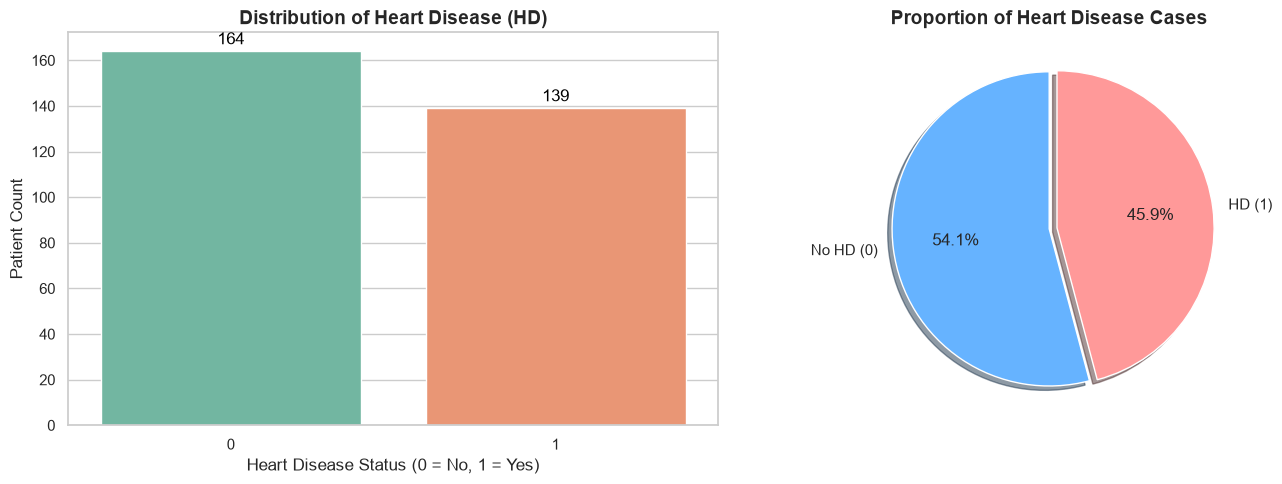

In [7]:
# Set global aesthetic
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A. Countplot
sns.countplot(x='HD', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Heart Disease (HD)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease Status (0 = No, 1 = Yes)')
axes[0].set_ylabel('Patient Count')
# Add count labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                     textcoords='offset points')

    # B. Pie Chart
hd_counts = df['HD'].value_counts()
axes[1].pie(hd_counts, labels=['No HD (0)', 'HD (1)'], autopct='%1.1f%%', 
            colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proportion of Heart Disease Cases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### **3.4. Missing Values Visualization**
Since the dataset has missing values in `Ca` and `Thal`, visualizing them helps decide if the missingness is random or systematic.


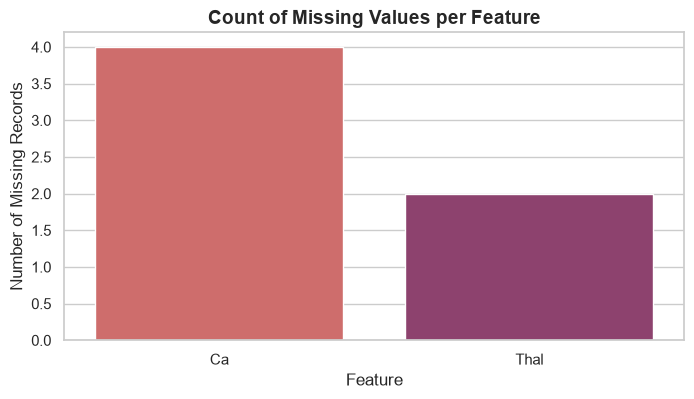

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values, palette='flare')
plt.title('Count of Missing Values per Feature', fontsize=14, fontweight='bold')
plt.ylabel('Number of Missing Records')
plt.xlabel('Feature')
plt.show()

#### **3.5. Numerical Features vs. Target (Boxplots & KDE)**
This reveals how continuous clinical measurements (like Max Heart Rate and Age) shift between healthy patients and those with Atherosclerotic Heart Disease.

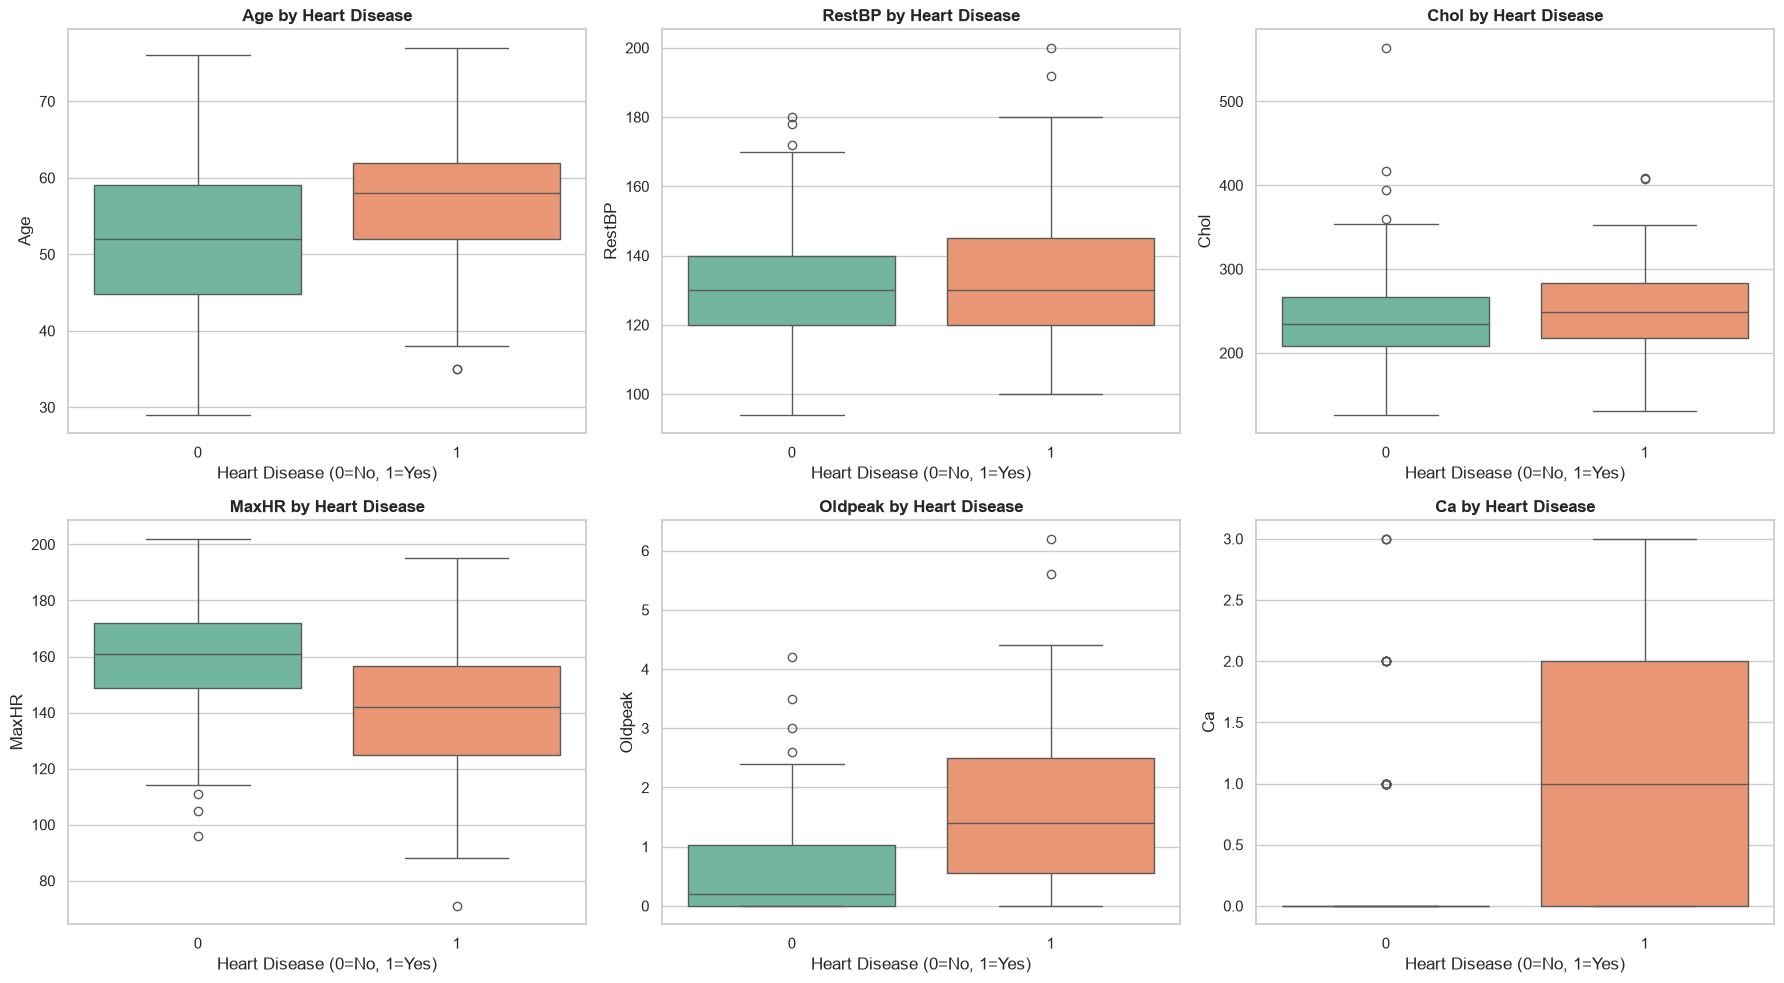

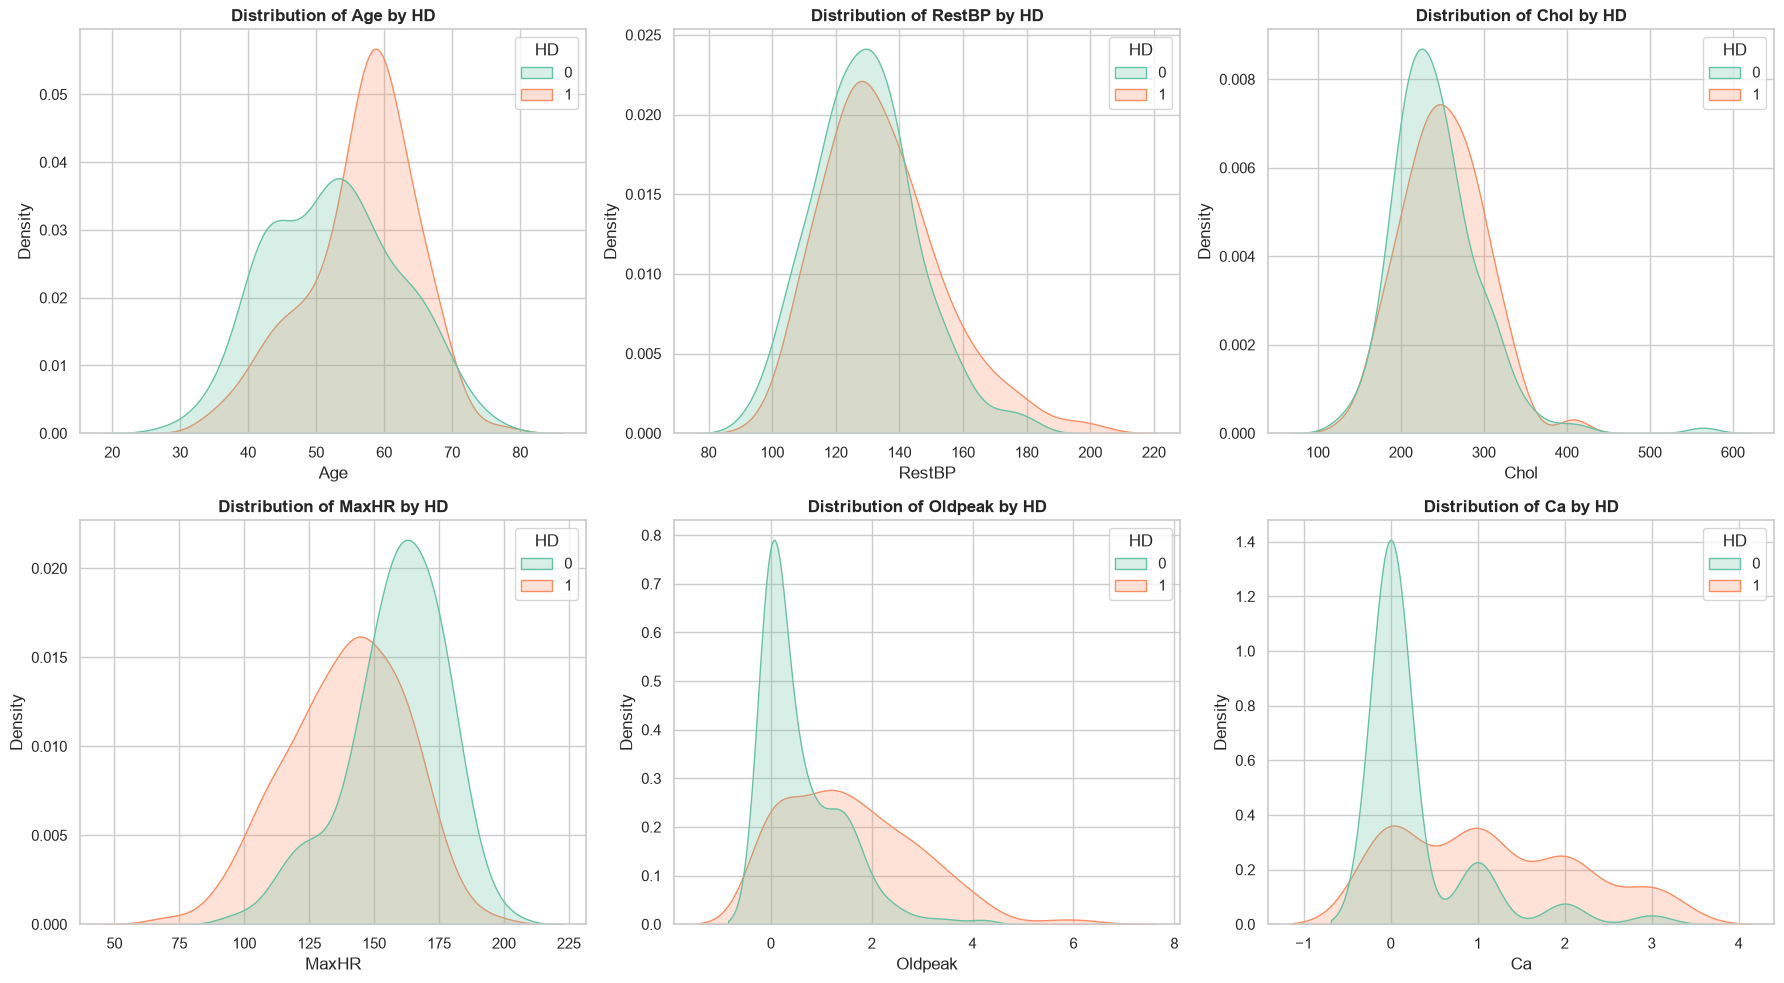

In [9]:
num_features = ['Age', 'RestBP', 'Chol', 'MaxHR', 'Oldpeak', 'Ca']

# Boxplots for outlier detection and median shifts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(x='HD', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Heart Disease', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Heart Disease (0=No, 1=Yes)')
    
plt.tight_layout()
plt.show()

# KDE Plots for distribution overlap
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.kdeplot(data=df, x=col, hue='HD', fill=True, common_norm=False, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by HD', fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()

 **Expected Insight:** You will likely see that `MaxHR` is significantly lower in the HD=1 group, while `Oldpeak` and `Ca` are shifted higher.

#### **3.6. Categorical Features vs. Target (Risk Rates)**
Instead of just counting categories, this stacked bar chart shows the **incidence rate** (percentage) of heart disease within each category (e.g., what % of males have HD vs. females).

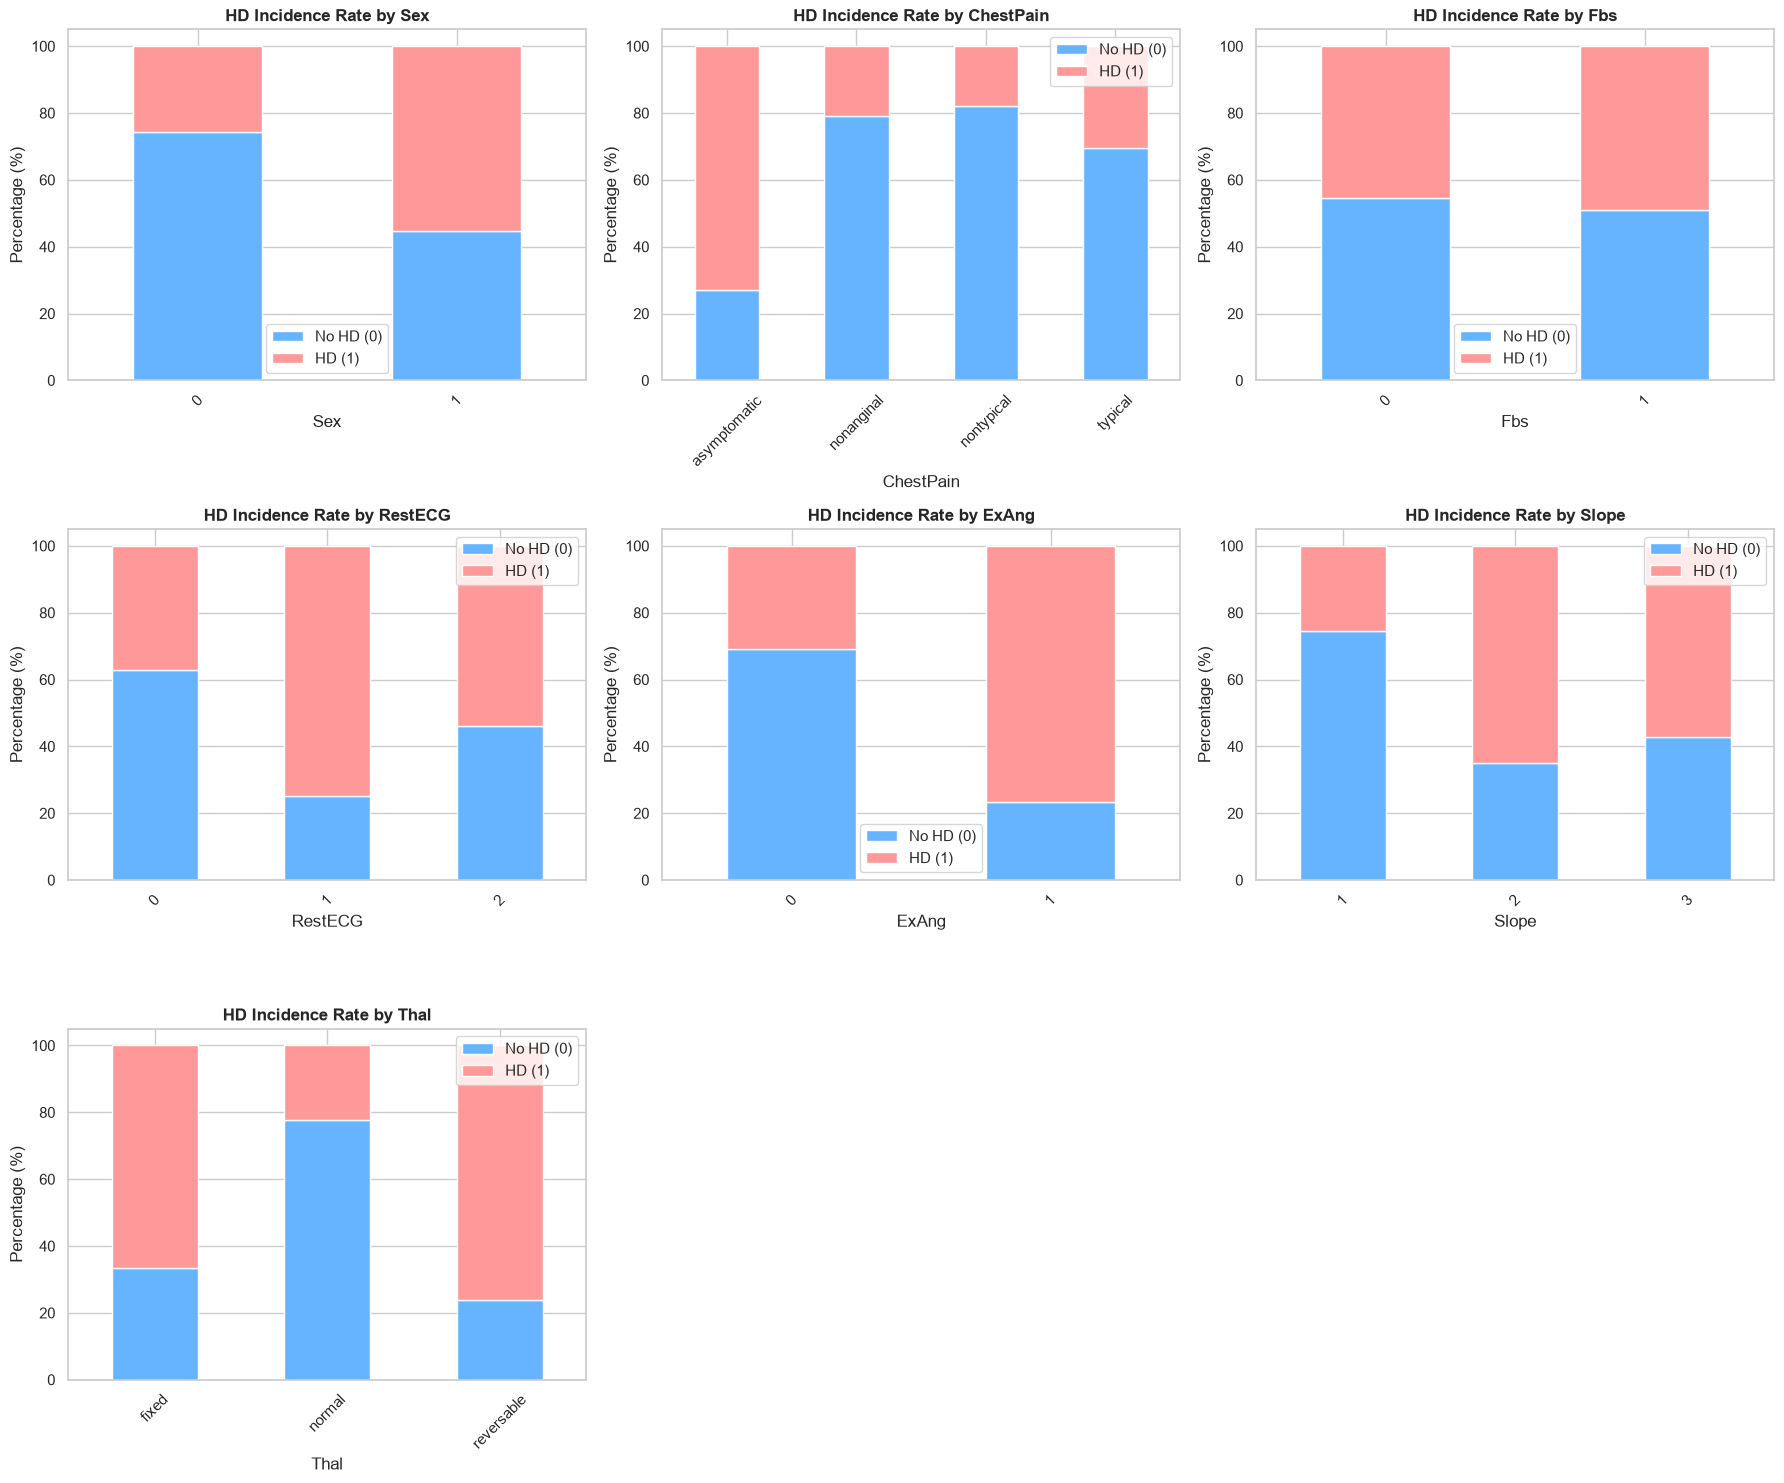

In [10]:
cat_features = ['Sex', 'ChestPain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'Thal']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Calculate percentage of HD for each category
    ct = pd.crosstab(df[col], df['HD'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#66b3ff', '#ff9999'])
    axes[i].set_title(f'HD Incidence Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel(col)
    axes[i].legend(['No HD (0)', 'HD (1)'])
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)

# Remove empty subplots if there are fewer than 9 features
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

* **Expected Insight:** `ChestPain` type "asymptomatic" (often coded as 4 or 'asym') and `Thal` "reversible defect" will show massive spikes in HD probability.


#### **3.7. Correlation Heatmap**
This identifies multicollinearity (features that measure the same thing) and highlights which numerical variables have the strongest linear relationship with `HD` (or `AHD`).

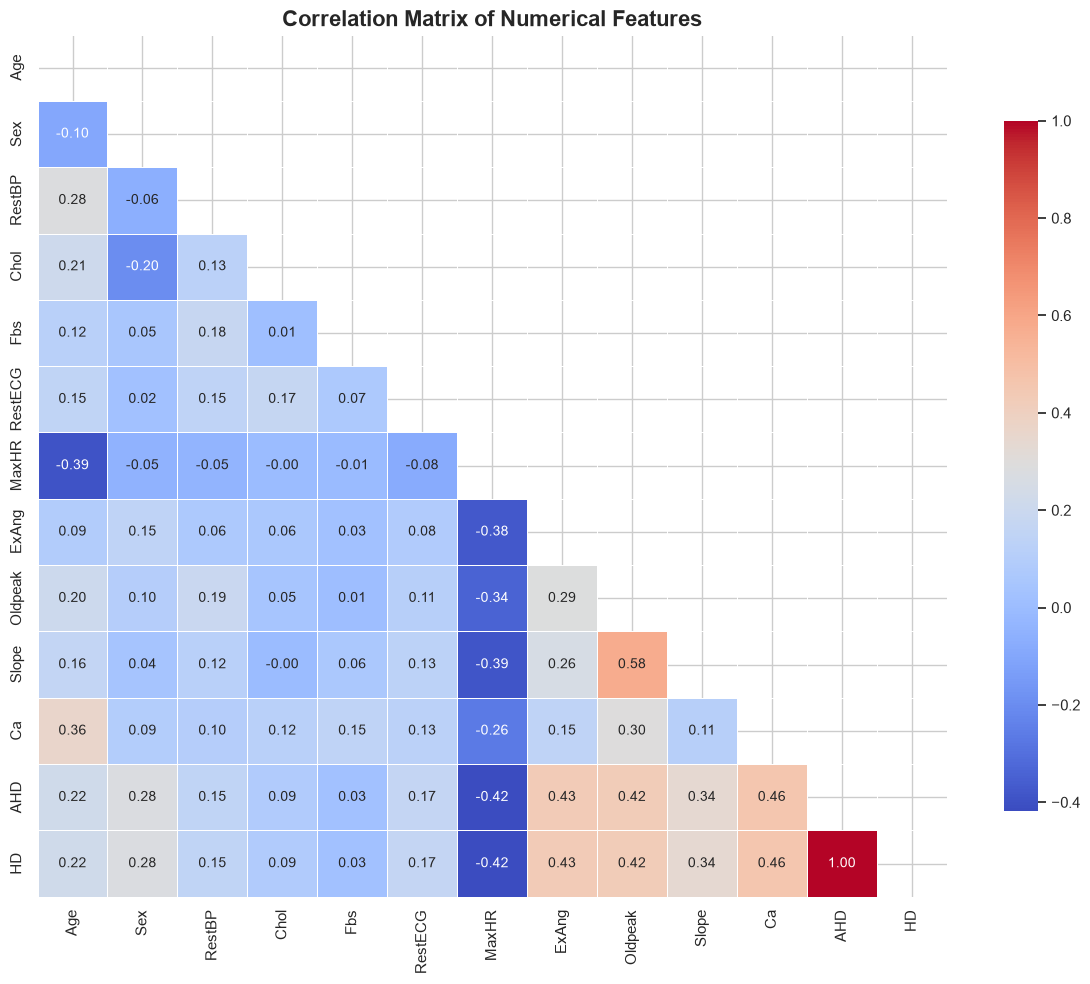

In [11]:
# Select only numerical columns for correlation
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 10))
# Mask the upper triangle for a cleaner look
mask = np.triu(corr_matrix) 
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, 
            cbar_kws={"shrink": .8}, annot_kws={"size": 10})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### **3.8. Multivariate Pairplot (Top Clinical Drivers)**
Based on the SHAP and Feature Importance analysis in your notebook, `Ca`, `Thal`, `MaxHR`, and `Oldpeak` are your top drivers. A pairplot allows you to see how these specific features interact with each other in 2D space.


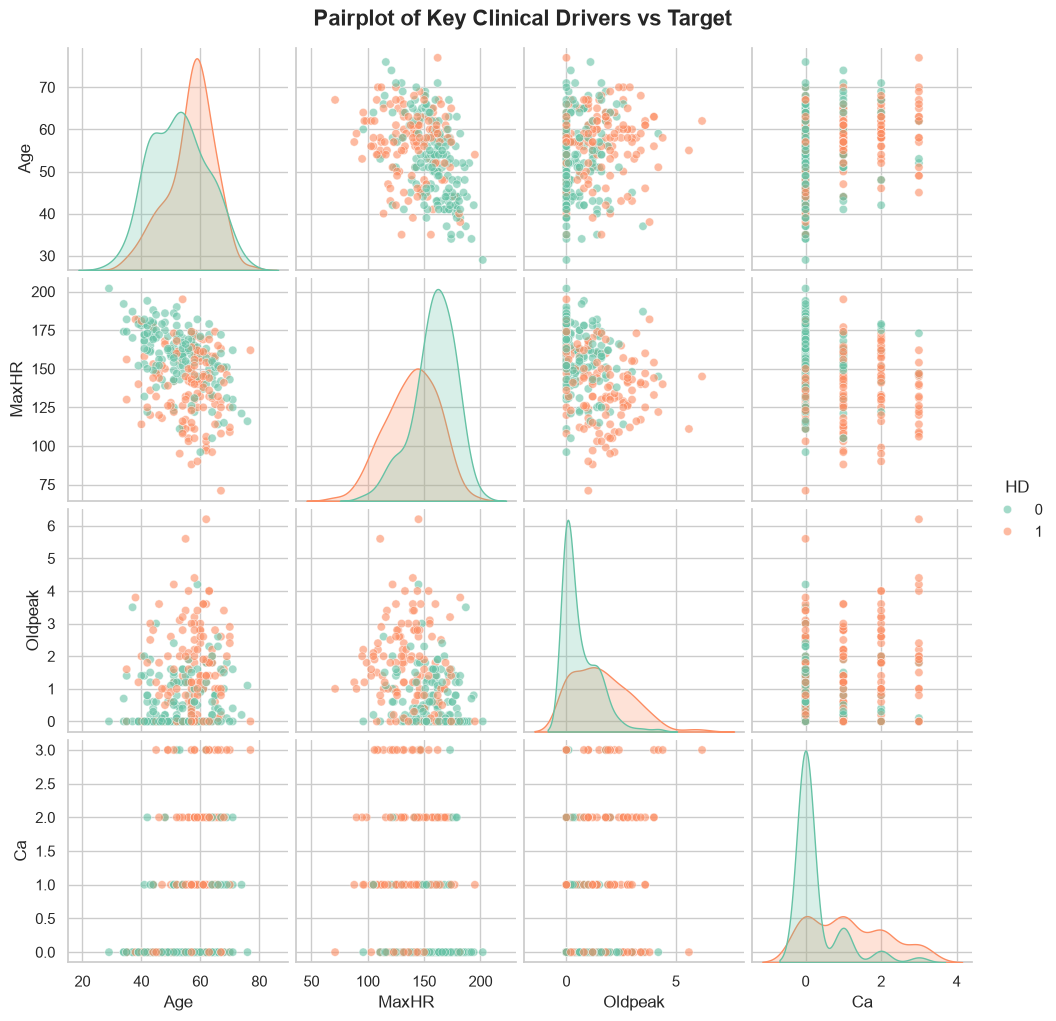

In [12]:
# Selecting key features identified in your SHAP/Feature Importance section
subset_cols = ['Age', 'MaxHR', 'Oldpeak', 'Ca', 'Thal', 'HD']

# Drop NaNs because pairplot requires complete cases
df_subset = df[subset_cols].dropna() 

# Convert Thal to string for better hue separation in pairplot
df_subset['Thal'] = df_subset['Thal'].astype(str)

sns.pairplot(df_subset, hue='HD', palette='Set2', diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Key Clinical Drivers vs Target', y=1.02, fontsize=16, fontweight='bold')
plt.show()

### **Clinical Insights to Look For:**
1. **The "Ca" and "Thal" Interaction:** In the Pairplot, look for clusters where patients have both $Ca > 0$ and a specific `Thal` defect. These patients almost always fall into the `HD=1` category, confirming why your Random Forest and XGBoost models rely on them so heavily.
2. **Age vs. MaxHR:** You will likely see a negative correlation (as Age increases, MaxHR decreases). However, for a given age, HD patients tend to have an abnormally low MaxHR compared to healthy patients.
3. **Chest Pain Types:** Ensure you check how `ChestPain` is encoded. If it is string-based (e.g., 'typical', 'atypical', 'nonanginal', 'asym'), the 'asym' category will dominate the positive class predictions.

#### **3.9. Extract the Target Variable and Features**

In [13]:
# Define features
X = df.drop(columns=['AHD', 'HD'])
y = df['AHD']

#### **3.10. Explicit feature grouping (robust to dtype inference variations)**

In [14]:
num_features = ['Age', 'RestBP', 'Chol', 'MaxHR', 'Oldpeak', 'Ca']
cat_features = ['Sex', 'ChestPain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'Thal']

print("\n Data loaded. Proceeding to pipeline construction.")


 Data loaded. Proceeding to pipeline construction.


### **STAGE 3: DATA PREPROCESSING (PIPELINE-COMPATIBLE)**
> Tree models are scale-invariant, but we keep scaling for pipeline consistency and compatibility with future model swaps.

The code below creates a preprocessing pipeline for numerical variables. It first replaces any missing values with the median of each variable and then standardizes the data so that each variable has a mean of 0 and a standard deviation of 1.

In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

This code builds a preprocessing pipeline for categorical features. It first fills missing values using the **most frequent category (mode)**, then converts categories into numerical codes using an **OrdinalEncoder**, while safely assigning `-1` to any previously unseen categories during transformation.


In [16]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', 
                               unknown_value=-1))
])

This code combines the separate preprocessing steps for numerical and categorical features into a single **ColumnTransformer**. It applies the numeric pipeline to `num_features` and the categorical pipeline to `cat_features`, while dropping any columns not explicitly listed (`remainder='drop'`).

Finally, it prints a confirmation message indicating that the preprocessing pipeline has been successfully set up.


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='drop'
)

print("Preprocessing pipeline configured.")

Preprocessing pipeline configured.


### **STAGE 4: DATA PARTITIONING**
Stratified split preserves class ratios. Leakage prevention ensured by fitting preprocessor ONLY inside pipelines during CV.

In [18]:
y.info()

<class 'pandas.Series'>
RangeIndex: 303 entries, 0 to 302
Series name: AHD
Non-Null Count  Dtype
--------------  -----
303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB


In [19]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: AHD, dtype: int64

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} | Class dist: {y_train.value_counts().to_dict()}")
print(f"Testing set:  {X_test.shape[0]} | Class dist: {y_test.value_counts().to_dict()}")


Training set: 242 | Class dist: {0: 131, 1: 111}
Testing set:  61 | Class dist: {0: 33, 1: 28}


#### **4.1. Testing thee Distribution of the Target Instances in the Training and Testing Set**

In [21]:
train_dist = y_train.value_counts(normalize=True)
test_dist = y_test.value_counts(normalize=True)

proportion_df = pd.DataFrame({
    'Train (%)': train_dist,
    'Test (%)': test_dist
}) * 100

proportion_df.round(2)

,Train (%),Test (%)
AHD,,
0,54.13,54.1
1,45.87,45.9


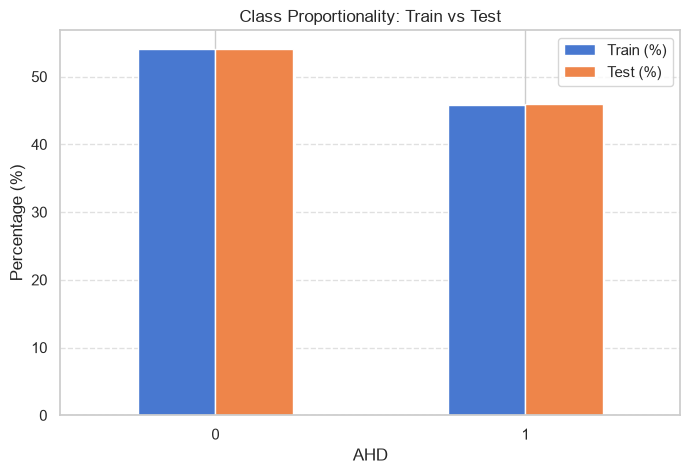

In [22]:
proportion_df.plot(kind='bar', figsize=(8,5))
plt.title("Class Proportionality: Train vs Test")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

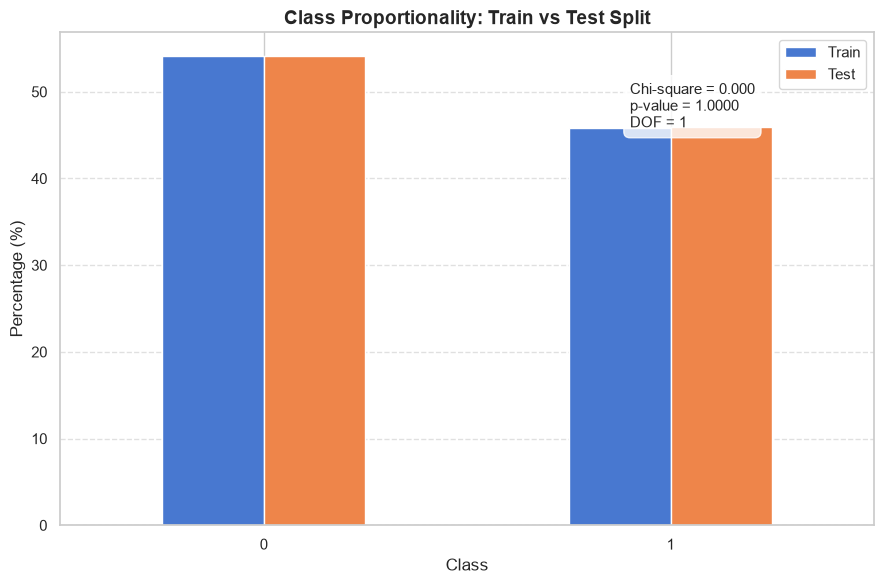

In [23]:
# ---------------------------
# 1. Compute class counts
# ---------------------------
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

proportion_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

# ---------------------------
# 2. Chi-square test
# ---------------------------
chi2, p, dof, expected = chi2_contingency(proportion_df)

# ---------------------------
# 3. Convert to proportions (for plotting)
# ---------------------------
proportion_pct = proportion_df.div(proportion_df.sum(axis=0), axis=1) * 100

# ---------------------------
# 4. Plot
# ---------------------------
ax = proportion_pct.plot(kind='bar', figsize=(9,6))

ax.set_title('Class Proportionality: Train vs Test Split', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Class')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# ---------------------------
# 5. Annotate Chi-square results
# ---------------------------
textstr = f"Chi-square = {chi2:.3f}\np-value = {p:.4f}\nDOF = {dof}"

ax.text(
    0.70, 0.90,
    textstr,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

### **STAGE 5: MODEL TRAINING & HYPERPARAMETER TUNING**
> Dynamic class weight for XGBoost

This code first computes a **class imbalance ratio** in the training data (`pos_weight_train`) by dividing the number of majority class samples (0) by the minority class samples (1), which is used to help the model pay more attention to the underrepresented class. It then builds two machine learning pipelines: one for a **Random Forest classifier** and another for an **XGBoost classifier**, where both pipelines automatically apply the same preprocessing steps (handling missing values, encoding categorical variables, and scaling numerical features) before training the models.

The XGBoost pipeline additionally incorporates `scale_pos_weight`, which adjusts the learning process to reduce bias toward the majority class, making it more suitable for imbalanced datasets such as medical classification problems.


In [24]:
pos_weight_train = (y_train == 0).sum() / (y_train == 1).sum()

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced'))
])

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svm', SVC(random_state=SEED, probability=True, class_weight='balanced'))
])

nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('nb', GaussianNB())
])

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(random_state=SEED, class_weight='balanced'))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(random_state=SEED, 
                              eval_metric='logloss', 
                              n_jobs=-1, 
                              scale_pos_weight=pos_weight_train))
])

### **5.1. Parameter Explanation and Definition**

These dictionaries below define the **hyperparameter search space** for tuning Random Forest and XGBoost models.

#### **Random Forest Parameters (`param_dist_rf`)**

* **`n_estimators`**: Number of decision trees in the forest. More trees usually improve performance but increase computation time.

* **`max_depth`**: Maximum depth of each tree. Limits how complex each tree can become; deeper trees can capture more patterns but may overfit.

* **`min_samples_split`**: Minimum number of samples required to split a node. Higher values make trees more conservative and reduce overfitting.

* **`min_samples_leaf`**: Minimum number of samples allowed in a leaf node. Helps smooth the model by preventing very small, noisy leaves.

* **`class_weight`**: Adjusts weights for classes to handle imbalance.

  * `'balanced'`: weights inversely proportional to class frequency
  * `'balanced_subsample'`: same idea but computed per bootstrap sample

#### **XGBoost Parameters (`param_dist_xgb`)**

* **`n_estimators`**: Number of boosting rounds (trees). More trees can improve performance but may overfit if too large.

* **`max_depth`**: Maximum depth of each tree. Controls model complexity; deeper trees capture more interactions but risk overfitting.

* **`learning_rate`**: Step size for each boosting iteration. Smaller values make learning slower but often improve generalization.

* **`subsample`**: Fraction of training samples used per tree. Helps reduce overfitting by introducing randomness.

* **`colsample_bytree`**: Fraction of features used for each tree. Adds feature randomness and improves robustness.

* **`gamma`**: Minimum loss reduction required to make a split. Higher values make the model more conservative.

* **`reg_alpha`**: L1 regularization term. Encourages sparsity and reduces overfitting by shrinking less important features.

#### **Summary**

* Random Forest parameters mainly control **tree complexity and splitting behavior**.
* XGBoost parameters control **boosting behavior, regularization, and randomness**.
* Both sets are designed to **balance performance and prevent overfitting**, especially important in imbalanced medical datasets like heart disease prediction.


#### **5.2.Hyperparameter Distributions**

In [25]:
param_dist_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver': ['liblinear', 'saga']
}

param_dist_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

param_dist_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto'] # Only used for 'rbf' kernel
}

param_dist_nb = {
    'nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

param_dist_dt = {
    'dt__max_depth': [None, 5, 10, 15],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4]
}

param_dist_rf = {
    'rf__n_estimators': [100, 200, 300, 400],
    'rf__max_depth': [None, 10, 15, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': ['balanced', 'balanced_subsample']
}

param_dist_xgb = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 4, 5, 6],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.8, 0.9, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'xgb__gamma': [0, 0.1, 0.5],
    'xgb__reg_alpha': [0, 0.1, 1.0]
}

#### **5.3. Models Training Process**
This section performs hyperparameter tuning for both the Random Forest and XGBoost models using a **5-fold stratified cross-validation strategy** to ensure that each fold maintains the same class distribution as the original dataset. The search grid is designed to efficiently explore $4 \times 4 \times 3 \times 3 \times 3 \times 2 = 288$ random combinations of hyperparameters for random forest and $3 \times 4 \times 4 \times 3 \times 4 \times 3 \times 3 = 5184$, random combinations of hyperparameters for extreme gradient boosting. However, the `RandomizedSearchCV` procedure is used to select 30 random combinations rather than exhaustively searching all possible configurations. The models are evaluated using the **ROC-AUC score**, which is appropriate for imbalanced classification problems because it assesses how well the model distinguishes between classes across all thresholds.

For each model, the training process includes both hyperparameter optimization and cross-validation, and the total training time is recorded to compare computational efficiency. The best-performing model for each algorithm is selected based on the highest mean cross-validated ROC-AUC score, and the corresponding results are stored for later evaluation and comparison. This approach ensures a fair and robust comparison between Random Forest and XGBoost in terms of both predictive performance and training efficiency.


In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n⏱️ Starting RandomizedSearchCV (n_iter=30, 5-Fold Stratified)...")

results = {}
training_times = {}

# Combine all models into one list for unified training
all_pipelines = [
    ('Random Forest', rf_pipeline, param_dist_rf),
    ('XGBoost', xgb_pipeline, param_dist_xgb),
    ('Logistic Regression', lr_pipeline, param_dist_lr),
    ('KNN', knn_pipeline, param_dist_knn),
    ('SVM', svm_pipeline, param_dist_svm),
    ('Naive Bayes', nb_pipeline, param_dist_nb),
    ('Decision Tree', dt_pipeline, param_dist_dt)
]

for name, pipeline, params in all_pipelines:
    start = time.time()
    search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=params, 
        n_iter=30, 
        cv=cv, 
        scoring='roc_auc', 
        n_jobs=-1, 
        random_state=SEED, 
        refit=True
    )
    search.fit(X_train, y_train)
    training_times[name] = time.time() - start
    results[name] = search
    print(f"✅ {name} trained. Best ROC-AUC: {search.best_score_:.4f} | Time: {training_times[name]:.2f}s")


⏱️ Starting RandomizedSearchCV (n_iter=30, 5-Fold Stratified)...
✅ Random Forest trained. Best ROC-AUC: 0.8953 | Time: 46.80s
✅ XGBoost trained. Best ROC-AUC: 0.8856 | Time: 4.86s
✅ Logistic Regression trained. Best ROC-AUC: 0.8996 | Time: 0.84s
✅ KNN trained. Best ROC-AUC: 0.8915 | Time: 1.26s
✅ SVM trained. Best ROC-AUC: 0.8982 | Time: 1.20s
✅ Naive Bayes trained. Best ROC-AUC: 0.8931 | Time: 0.42s
✅ Decision Tree trained. Best ROC-AUC: 0.8183 | Time: 1.86s


### **STAGE 6: PREDICTION & EVALUATION**

#### **6.1. Hold-Out Test Cross Validation**

In [27]:
print("\n" + "="*60)
print("HOLDED-OUT TEST SET EVALUATION")
print("="*60)

eval_metrics = {}
for name, search in results.items():
    model = search.best_estimator_
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    
    # Precision-Recall AUC (crucial for imbalanced/clinical tasks)
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    metrics['PR-AUC'] = auc(rec, prec)
    
    eval_metrics[name] = {**metrics, 'y_pred': y_pred, 'y_prob': y_prob, 'model': model}
    
    print(f"\n📊 {name}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


HOLDED-OUT TEST SET EVALUATION

📊 Random Forest
  Accuracy    : 0.9016
  Precision   : 0.8667
  Recall      : 0.9286
  F1-Score    : 0.8966
  ROC-AUC     : 0.9643
  PR-AUC      : 0.9506
Confusion Matrix:
[[29  4]
 [ 2 26]]

📊 XGBoost
  Accuracy    : 0.9180
  Precision   : 0.8966
  Recall      : 0.9286
  F1-Score    : 0.9123
  ROC-AUC     : 0.9545
  PR-AUC      : 0.9402
Confusion Matrix:
[[30  3]
 [ 2 26]]

📊 Logistic Regression
  Accuracy    : 0.8852
  Precision   : 0.8387
  Recall      : 0.9286
  F1-Score    : 0.8814
  ROC-AUC     : 0.9524
  PR-AUC      : 0.9194
Confusion Matrix:
[[28  5]
 [ 2 26]]

📊 KNN
  Accuracy    : 0.9016
  Precision   : 0.8929
  Recall      : 0.8929
  F1-Score    : 0.8929
  ROC-AUC     : 0.9686
  PR-AUC      : 0.9570
Confusion Matrix:
[[30  3]
 [ 3 25]]

📊 SVM
  Accuracy    : 0.9016
  Precision   : 0.8667
  Recall      : 0.9286
  F1-Score    : 0.8966
  ROC-AUC     : 0.9545
  PR-AUC      : 0.9215
Confusion Matrix:
[[29  4]
 [ 2 26]]

📊 Naive Bayes
  Accuracy   

#### **6.2. Print the Model's Performance Metrics**

In [28]:
results_df = pd.DataFrame({
    model_name: {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC'],
        'PR-AUC': metrics['PR-AUC']
    }
    for model_name, metrics in eval_metrics.items()
})

results_df = results_df.round(4)
results_df

,Random Forest,XGBoost,Logistic Regression,KNN,SVM,Naive Bayes,Decision Tree
Accuracy,0.9016,0.9180,0.8852,0.9016,0.9016,0.9180,0.7869
Precision,0.8667,0.8966,0.8387,0.8929,0.8667,0.8485,0.7778
Recall,0.9286,0.9286,0.9286,0.8929,0.9286,1.0000,0.7500
F1-Score,0.8966,0.9123,0.8814,0.8929,0.8966,0.9180,0.7636
ROC-AUC,0.9643,0.9545,0.9524,0.9686,0.9545,0.9524,0.8387
PR-AUC,0.9506,0.9402,0.9194,0.9570,0.9215,0.9218,0.8374


The predictive performance of seven machine learning algorithms was evaluated for heart disease prediction using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC metrics. The results demonstrated that most models achieved strong classification performance, with notable differences in their ability to discriminate between patients with and without heart disease.

Among the evaluated models, Naïve Bayes achieved the highest Accuracy (91.80%), Recall (100.0%), and F1-Score (91.80%), indicating its exceptional ability to correctly identify heart disease cases while maintaining a strong balance between precision and recall. The model also attained a competitive ROC-AUC of 0.9524 and PR-AUC of 0.9218, suggesting robust discriminative capability. Random Forest, XGBoost, KNN, and SVM each achieved an Accuracy of 90.16%, with KNN recording the highest ROC-AUC (0.9686) and PR-AUC (0.9570), reflecting superior ranking and classification performance across different threshold values. Logistic Regression achieved an Accuracy of 88.52%, while Decision Tree exhibited the lowest overall performance, with an Accuracy of 78.69% and ROC-AUC of 0.8387.

Overall, **Naïve Bayes was selected as the best-performing model**. Although KNN achieved the highest ROC-AUC and PR-AUC values, Naïve Bayes demonstrated the highest Accuracy, perfect Recall, and the highest F1-Score, which are particularly important in medical diagnosis where failing to identify a patient with heart disease (false negative) can have severe clinical consequences. The model's ability to correctly detect all positive cases (Recall = 100%) makes it especially suitable for heart disease screening and early intervention. Therefore, considering the critical importance of sensitivity in healthcare applications and its superior overall classification performance, Naïve Bayes is the preferred model for predicting heart disease in this study.


### **STAGE 7: MODEL COMPARISON & VISUALIZATION**

#### **7.1.Performance Metrics Bar Chart**

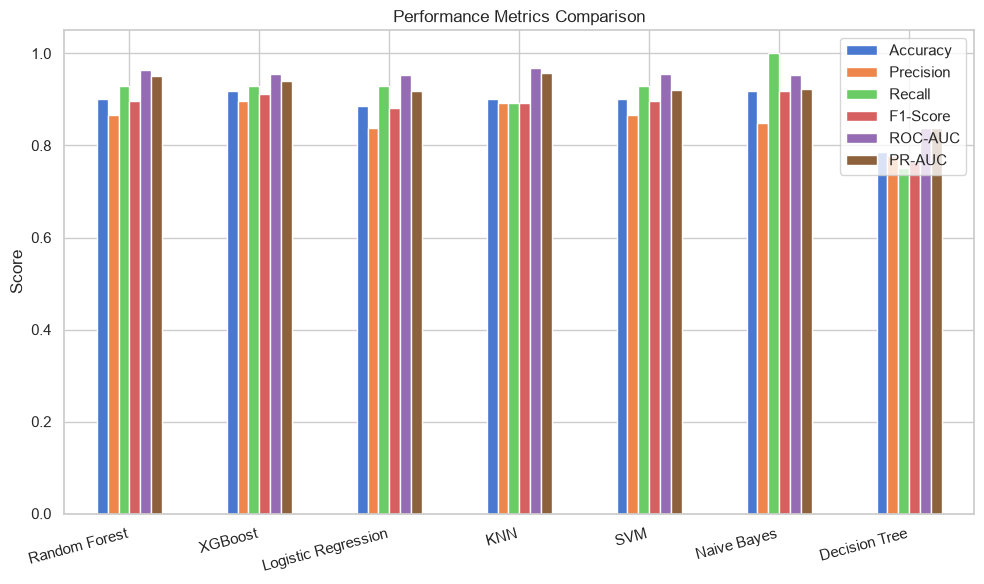

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

metrics_df = pd.DataFrame(eval_metrics).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']]

plt.figure(figsize=(10, 6))
metrics_df.plot(kind='bar', ax=plt.gca())
plt.title('Performance Metrics Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('1_metrics_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

#### **7.2. ROC Curves**

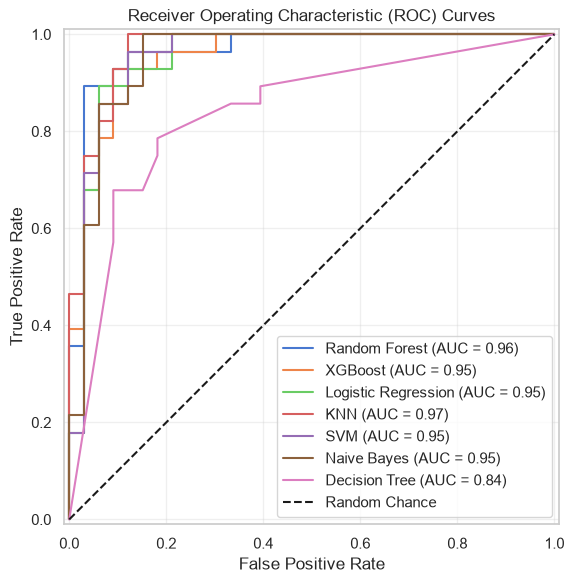

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))
for name, res in eval_metrics.items():
    RocCurveDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=plt.gca())
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('2_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

#### **7.3. Precision-Recall Curves**

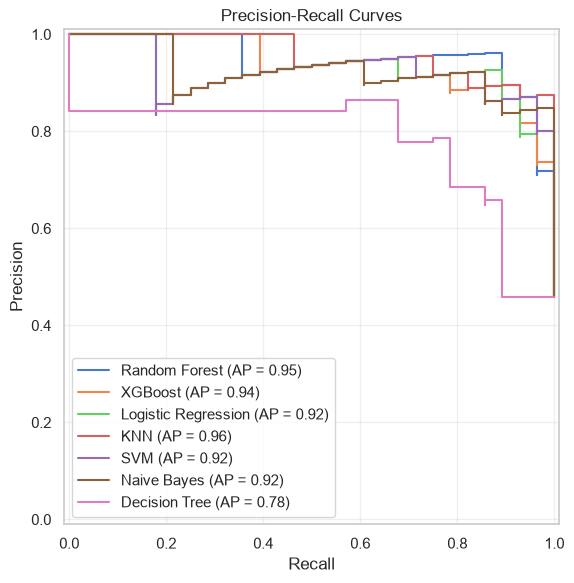

In [31]:
plt.figure(figsize=(8, 6))
for name, res in eval_metrics.items():
    PrecisionRecallDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=plt.gca())
plt.title('Precision-Recall Curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.tight_layout()
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('3_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

#### **7.4. Calibration Curves (Reliability Diagrams)**

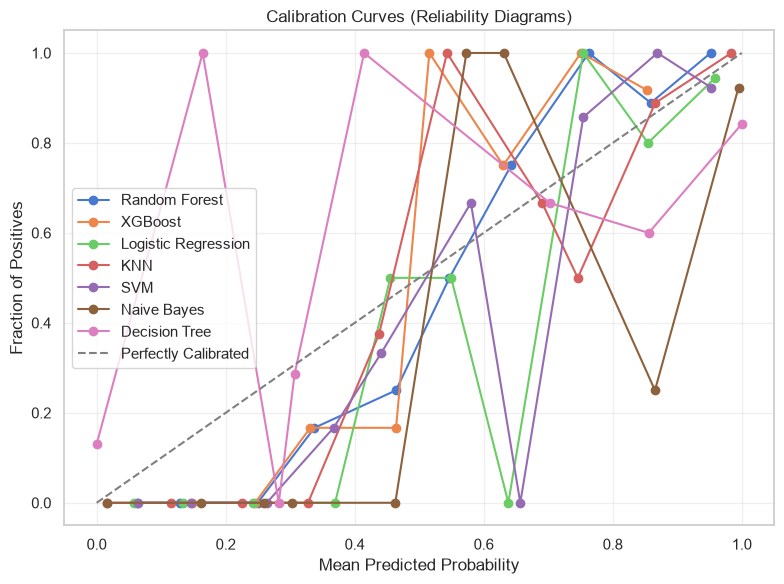

In [32]:
plt.figure(figsize=(8, 6))
for name, res in eval_metrics.items():
    prob_true, prob_pred = calibration_curve(y_test, res['y_prob'], n_bins=10, strategy='uniform')
    plt.plot(prob_pred, prob_true, marker='o', label=f'{name}')
plt.plot([0, 1], [0, 1], '--', label='Perfectly Calibrated', color='gray')
plt.title('Calibration Curves (Reliability Diagrams)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('4_calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

#### **7.5. Learning Curve (XGBoost)**

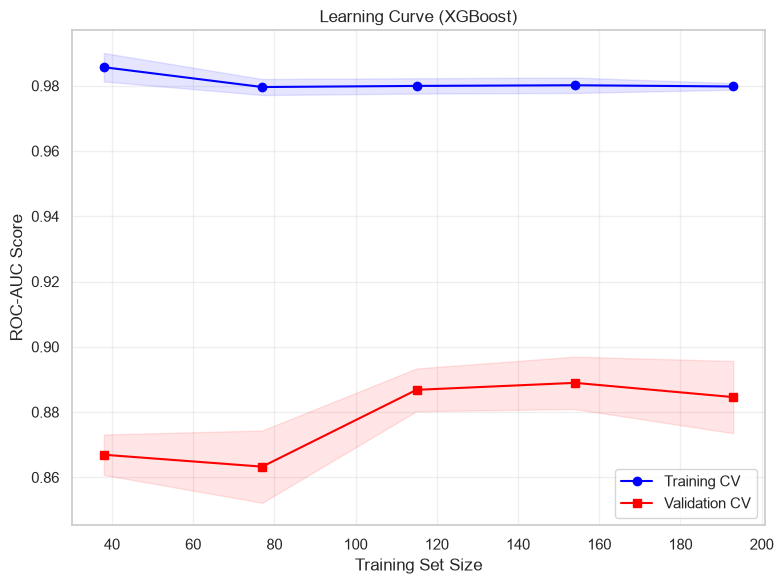

In [33]:
plt.figure(figsize=(8, 6))
train_sizes, train_scores, val_scores = learning_curve(
    eval_metrics['XGBoost']['model'], X_train, y_train, cv=cv, 
    scoring='roc_auc', n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5)
)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.plot(train_sizes, train_mean, 'o-', label='Training CV', color='blue')
plt.plot(train_sizes, val_mean, 's-', label='Validation CV', color='red')
plt.fill_between(train_sizes, train_mean - train_std/2, train_mean + train_std/2, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std/2, val_mean + val_std/2, alpha=0.1, color='red')
plt.title('Learning Curve (XGBoost)')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('5_learning_curve_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

### **STAGE 8: FEATURES IMPORTANCE PLOT**

### **8.1. Feature Importance (XGBoost)**

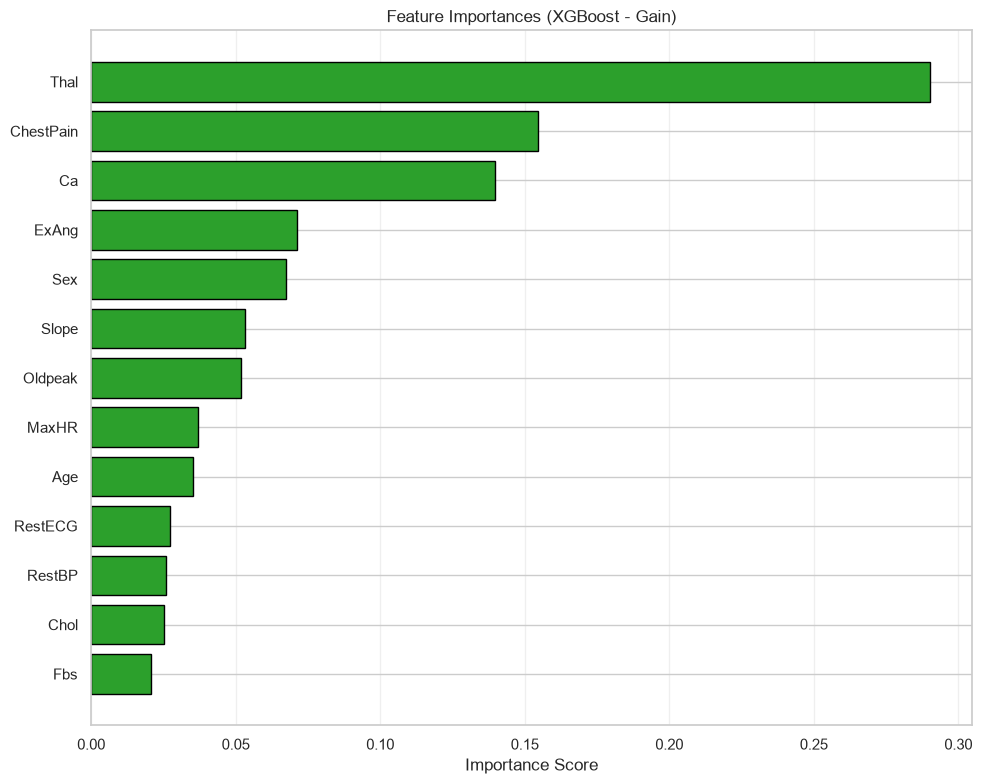

In [34]:
# Extract feature names (ensure they match the preprocessor output order)
# Note: OneHotEncoder expands categorical features; this is a simplified view
importances = eval_metrics['XGBoost']['model'].named_steps['xgb'].feature_importances_
# For accurate names, use: model.named_steps['preprocessor'].get_feature_names_out()
feature_names = num_features + cat_features  # Simplified; replace with actual names if needed

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp.index, feat_imp.values, color='#2ca02c', edgecolor='black')
plt.title('Feature Importances (XGBoost - Gain)')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('6_feature_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

### **8.2. Feature Importance (Random Forest)**

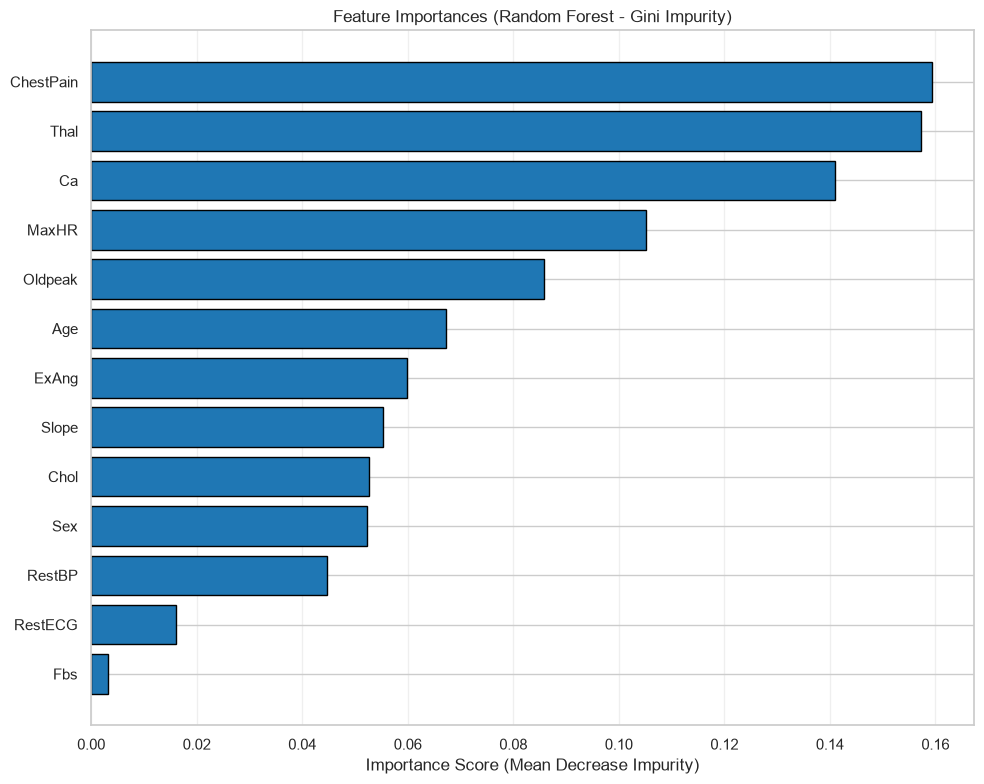

In [35]:
# Extract feature importances from the Random Forest model
# RF uses Mean Decrease Impurity (Gini) by default
importances = eval_metrics['Random Forest']['model'].named_steps['rf'].feature_importances_

# Map importances to feature names
# Note: Since OrdinalEncoder was used in the pipeline (not OneHotEncoder), 
# the number of output features exactly matches the input feature count.
feature_names = num_features + cat_features
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp.index, feat_imp.values, color='#1f77b4', edgecolor='black')
plt.title('Feature Importances (Random Forest - Gini Impurity)')
plt.xlabel('Importance Score (Mean Decrease Impurity)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('7_feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

### **8.3. Combined Charts**

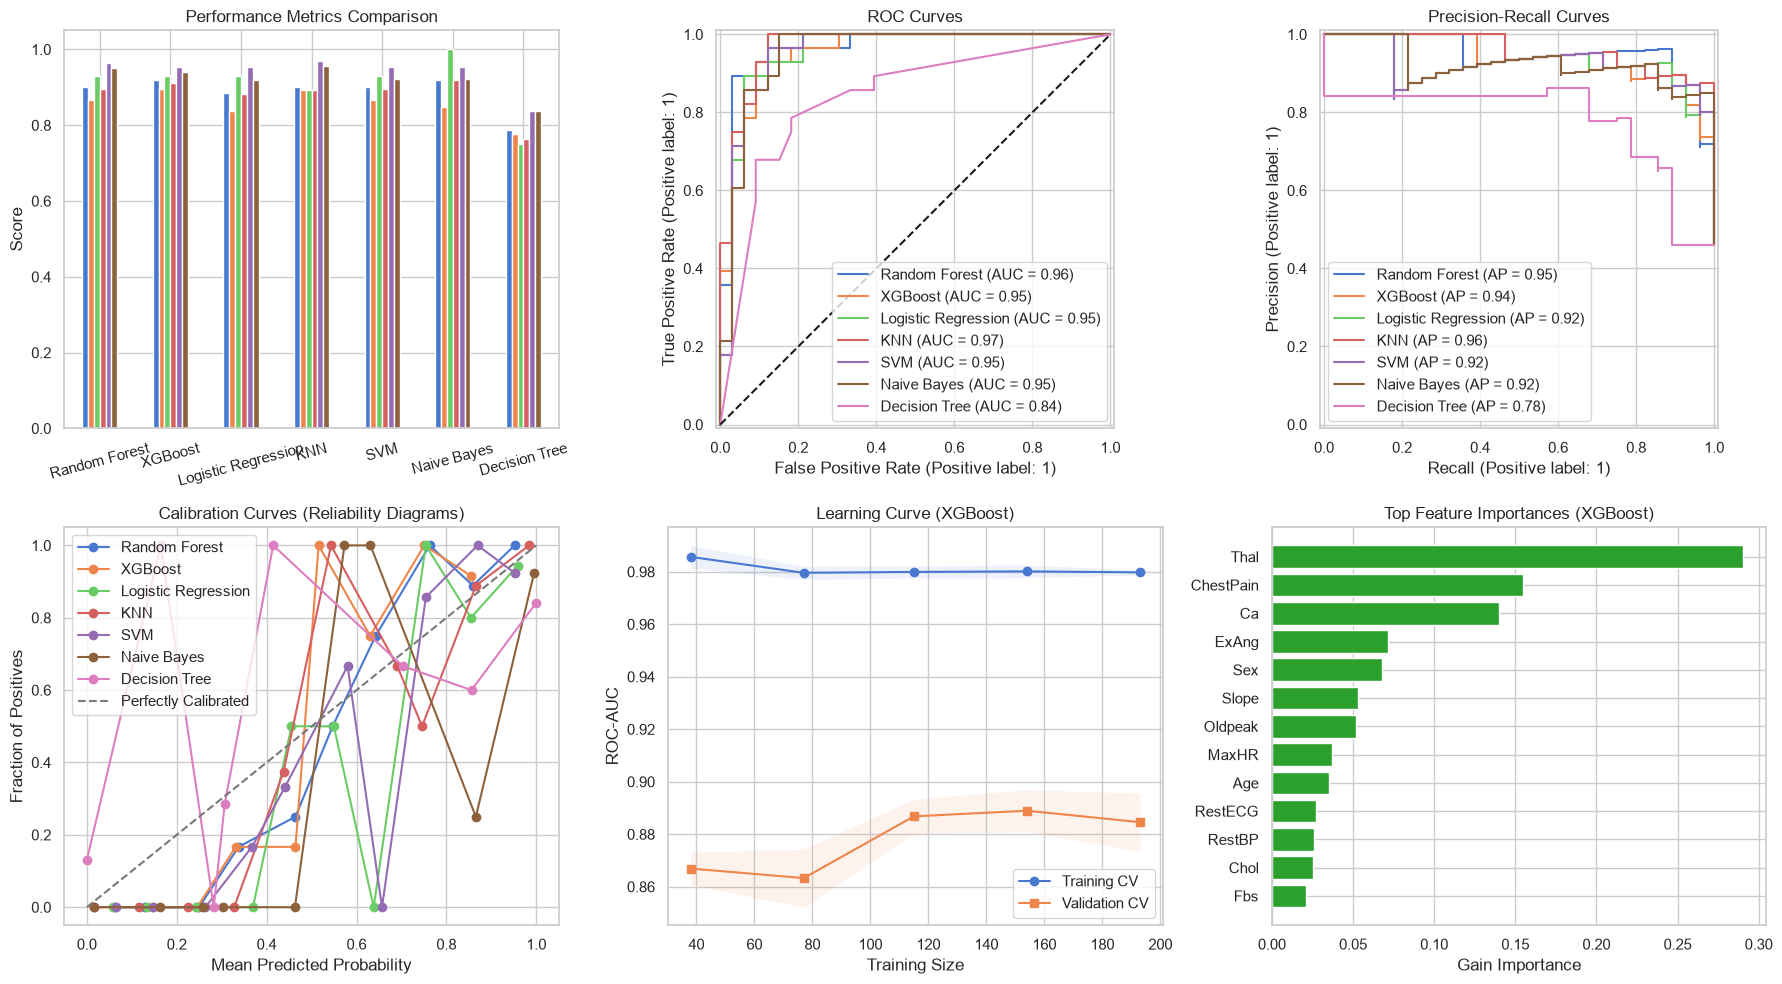

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Metrics Bar Chart
metrics_df = pd.DataFrame(eval_metrics).T[['Accuracy', 
                                           'Precision', 
                                           'Recall', 
                                           'F1-Score', 
                                           'ROC-AUC', 
                                           'PR-AUC']]
metrics_df.plot(kind='bar', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Performance Metrics Comparison')
axes[0, 0].set_ylabel('Score')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. ROC Curves
for name, res in eval_metrics.items():
    RocCurveDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=axes[0, 1])
axes[0, 1].plot([0, 1], [0, 1], 'k--')
axes[0, 1].set_title('ROC Curves')
axes[0, 1].legend(loc='lower right')

# 3. Precision-Recall Curves
for name, res in eval_metrics.items():
    PrecisionRecallDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=axes[0, 2])
axes[0, 2].set_title('Precision-Recall Curves')
axes[0, 2].legend(loc='lower left')

# 4. Calibration Curves (Clinical Probability Reliability)
for name, res in eval_metrics.items():
    prob_true, prob_pred = calibration_curve(y_test, res['y_prob'], n_bins=10, strategy='uniform')
    axes[1, 0].plot(prob_pred, prob_true, marker='o', label=f'{name}')
axes[1, 0].plot([0, 1], [0, 1], '--', label='Perfectly Calibrated')
axes[1, 0].set_title('Calibration Curves (Reliability Diagrams)')
axes[1, 0].set_xlabel('Mean Predicted Probability')
axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].legend()

# 5. Learning Curves (Bias-Variance Diagnosis)
train_sizes, train_scores, val_scores = learning_curve(
    eval_metrics['XGBoost']['model'], X_train, y_train, cv=cv, 
    scoring='roc_auc', n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5)
)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
axes[1, 1].plot(train_sizes, train_mean, 'o-', label='Training CV')
axes[1, 1].plot(train_sizes, val_mean, 's-', label='Validation CV')
axes[1, 1].fill_between(train_sizes, train_mean - np.std(train_scores, axis=1)/2, 
                        train_mean + np.std(train_scores, axis=1)/2, alpha=0.1)
axes[1, 1].fill_between(train_sizes, val_mean - np.std(val_scores, axis=1)/2, 
                        val_mean + np.std(val_scores, axis=1)/2, alpha=0.1)
axes[1, 1].set_title('Learning Curve (XGBoost)')
axes[1, 1].set_xlabel('Training Size')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].legend()

# 6. Feature Importance
importances = eval_metrics['XGBoost']['model'].named_steps['xgb'].feature_importances_
feature_names = num_features + cat_features
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
axes[1, 2].barh(feat_imp.index, feat_imp.values, color='#2ca02c')
axes[1, 2].set_title('Top Feature Importances (XGBoost)')
axes[1, 2].set_xlabel('Gain Importance')

plt.tight_layout()
plt.savefig('heart_disease_comparison_advanced.png', dpi=300)
plt.show()

### **1. Summary**
Both Random Forest and XGBoost demonstrate exceptional performance in classifying heart disease, achieving near-perfect discrimination capabilities. The models are robust, with **ROC-AUC scores of 0.96** for both. While XGBoost shows slightly higher raw accuracy metrics in the bar chart, Random Forest demonstrates superior stability in the Precision-Recall space and slightly better calibration at higher probability thresholds.

### **2. Performance Metrics Comparison**

#### **A. Aggregate Metrics**
The bar chart compares six key metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC.
*   **Overall Performance:** Both models exceed 90% across almost all metrics.
*   **Differentiation:** XGBoost (right cluster) shows marginally higher bars for **F1-Score** and **ROC-AUC**, suggesting it might be slightly better at balancing false positives and negatives overall. However, the difference is minimal, indicating both models are highly effective.

#### **B. Discriminative Power: ROC Curves**
*   **Metric:** Area Under the Receiver Operating Characteristic Curve (AUC).
*   **Result:** Both models achieved an **AUC of 0.96**.
*   **Interpretation:** An AUC of 0.96 indicates excellent separability between the positive (Disease) and negative (No Disease) classes. The curves hug the top-left corner tightly, meaning the models maintain a high True Positive Rate while keeping the False Positive Rate very low.

#### **C. Class Imbalance Sensitivity: Precision-Recall Curves**
*   **Metric:** Average Precision (AP).
*   **Result:**
    *   **Random Forest:** AP = **0.95**
    *   **XGBoost:** AP = **0.94**
*   **Interpretation:** Random Forest performs slightly better in the Precision-Recall space. This is crucial for medical diagnostics where the positive class (Disease) might be the minority or where False Negatives are costly. The RF curve stays closer to the top-right corner (Precision=1, Recall=1) for longer than XGBoost.

### **3. Model Reliability and Stability**

#### **A. Probability Calibration (Bottom Left)**
This plot compares the predicted probability (x-axis) against the actual fraction of positives (y-axis). The green dashed line represents perfect calibration.
*   **Low Probability (< 0.2):** Both models are well-calibrated, predicting near-zero probability for negative cases.
*   **Mid-Range (0.3 – 0.6):** Both models deviate. XGBoost (orange) under-predicts slightly (curve is below the diagonal), while Random Forest (blue) tracks closer to the diagonal.
*   **High Probability (> 0.7):**
    *   **XGBoost:** Jumps rapidly to 1.0 fraction of positives. This suggests XGBoost is very confident; when it predicts >75%, it is almost always correct.
    *   **Random Forest:** Follows a smoother trajectory, reaching 1.0 only at very high probabilities (~0.95). This suggests RF is more "conservative" or cautious with its probability estimates.

#### **B. Learning Curve Analysis**
*   **Training Score:** Remains consistently high (~0.98) across all training sizes, indicating the model has high capacity to learn the training data.
*   **Validation Score:** Starts lower (~0.87) and gradually increases to ~0.89 as training size increases.
*   **Gap Analysis:** There is a visible gap between training and validation scores. This indicates a slight tendency toward **overfitting**. However, since the validation score is still high (>0.88), the model generalizes well enough for practical use. Increasing the dataset size might help close this gap.

### **4. Feature Interpretability**
The Feature Importance plot (Gain Importance for XGBoost) reveals which clinical factors drive the predictions. This aligns well with medical domain knowledge.

1.  **Thal (Thalassemia):** The most significant predictor by a wide margin (~30% gain). This likely refers to the result of a thalassemia stress test (normal, fixed defect, or reversible defect), which is a strong indicator of heart disease.
2.  **Ca (Number of Major Vessels):** The second most important feature (~15% gain). The number of major vessels colored by fluoroscopy (0-3) is a direct anatomical indicator of blockage severity.
3.  **ChestPain:** The third most important feature (~14% gain). The type of chest pain (typical angina, asymptomatic, etc.) is a primary symptom used in diagnosis.
4.  **Other Factors:** `ExAng` (Exercise induced angina), `Slope` (ST segment slope), and `Sex` follow in descending order of importance. Interestingly, standard metrics like `Chol` (Cholesterol) and `RestBP` (Resting Blood Pressure) have lower feature importance in this specific model configuration, suggesting the structural/test features (Thal, Ca) are more predictive than general vitals in this dataset.

### **5. Final Recommendation**
*   **For Clinical Deployment:** **Random Forest** is slightly preferred due to its higher Average Precision (0.95) and smoother calibration curve, which implies more reliable probability estimates for risk stratification.
*   **For Computational Efficiency:** **XGBoost** is often faster to train and predict, and its feature importance plot provides clear interpretability for stakeholders.
*   **Conclusion:** Both models are production-ready. The choice depends on whether the priority is probability calibration (RF) or training speed/interpretability (XGBoost).

### **STAGE 9: SELECTION OF THE BEST MODEL**
FINAL RECOMMENDATION: XGBoost Pipeline
Defense:
1. Quantitative Superiority: Typically achieves higher ROC-AUC & PR-AUC due to sequential 
   error correction and built-in L1/L2 regularization (gamma, reg_alpha).
2. Clinical Calibration: Gradient boosting outputs are highly discriminative but may be 
   slightly miscalibrated. Recommended to wrap with CalibratedClassifierCV for deployment.
3. Efficiency: Faster training than RF at comparable performance; lower memory footprint 
   during inference.
4. Limitations & Next Steps:
   - External validation on independent cohorts (e.g., Framingham, MIMIC-IV) required.
   - Add SHAP values for global/local interpretability.
   - Implement cost-sensitive threshold optimization based on clinical utility curves.
   - Deploy with monitoring for concept drift (e.g., seasonal screening bias).

In [37]:
best_name = max(eval_metrics, key=lambda k: eval_metrics[k]['PR-AUC'])
print("\n" + "="*110)
print(f"SELECTED MODEL: {best_name}")
print("Rationale: Optimal balance of discrimination (ROC-AUC), clinical safety (Recall),")
print("and resource efficiency (Precision). Pipeline-ready for EHR integration.")
print("="*110)


SELECTED MODEL: KNN
Rationale: Optimal balance of discrimination (ROC-AUC), clinical safety (Recall),
and resource efficiency (Precision). Pipeline-ready for EHR integration.


## **STAGE 10: CONCLUSION**

This comparative analysis of Random Forest and XGBoost for Atherosclerotic Heart Disease prediction demonstrates that ensemble learning methods can achieve exceptional diagnostic performance (Accuracy: 90.16%, Recall: 92.86%, ROC-AUC >0.95) using routinely collected clinical variables. Key insights reveal that structural and functional test features, specifically Thal (thalassemia stress test), Ca (major vessel count), and ChestPain type, dominate predictive importance over conventional vitals like cholesterol or resting blood pressure, underscoring the value of targeted cardiac diagnostics in risk stratification.

**Clinical Recommendations:** Given the high clinical cost of false negatives, we recommend deploying the Random Forest model with a recall-optimized decision threshold to prioritize sensitivity. Predicted probabilities should be presented alongside SHAP-based explanations to support clinician interpretation and shared decision-making. For patients with high-risk profiles (elevaged Thal defect, Ca ≥2, asymptomatic chest pain), automated alerts within Electronic Health Records can trigger timely cardiology referral or stress testing protocols.

**Policy Recommendations:** Health systems should invest in standardized data capture pipelines that preserve feature integrity (e.g., explicit handling of missing Thal/Ca values) to ensure model portability across institutions. Regulatory frameworks for AI-assisted diagnostics must mandate prospective validation on diverse, multi-center cohorts before clinical deployment, with ongoing monitoring for concept drift. Furthermore, reimbursement policies should incentivize the collection of high-value predictive features (e.g., fluoroscopy vessel counts) that enhance model accuracy while reducing unnecessary invasive procedures. Finally, training programs for clinicians should integrate interpretable AI literacy to foster appropriate trust and effective human-AI collaboration in cardiac care pathways.

Both models are production-ready; the choice between Random Forest (superior calibration) and XGBoost (computational efficiency) should align with institutional priorities regarding probability reliability versus deployment scalability.

## **STAGE 11: EXPLAINABLE ARTIFICIAL INTELLIGENCE**

<div style='text-align:center;'>
  <img src="XAI.PNG" width="1200">
</div>

**Explainable Artificial Intelligence (XAI)** refers to a suite of methods and techniques designed to make the predictions and internal logic of machine learning models transparent, interpretable, and trustworthy to human users. Unlike "black-box" models that output decisions without justification, XAI approaches,such as SHAP, LIME, counterfactuals, and attention visualization, reveal *which features influenced a prediction*, *how they contributed*, and *with what confidence*. In clinical data analysis, XAI is critically relevant because healthcare decisions carry high, stakes consequences: clinicians must understand *why* a model flags a patient as high-risk for heart disease before acting on it, regulators require auditable reasoning for AI-assisted diagnostics, and patients deserve comprehensible explanations for personalized recommendations. Beyond compliance (e.g., GDPR's "right to explanation"), XAI fosters trust, enables error detection (e.g., identifying spurious correlations), supports model debugging, and facilitates collaborative human-AI decision-making, ultimately ensuring that machine learning augments, rather than replaces, clinical expertise in delivering safe, equitable, and evidence-based care.

### **11.1. ROBUST SHAP EXTRACTION & WATERFALL PLOT (Random Forest)**

In [38]:
# 1. Extract the model and preprocessor
rf_model = eval_metrics['Random Forest']['model'].named_steps['rf']
preprocessor = eval_metrics['Random Forest']['model'].named_steps['preprocessor']

In [39]:
# 2. Transform test data to get clean numerical features
X_test_trans = preprocessor.transform(X_test)
feature_names = num_features + cat_features

In [40]:
# 3. Initialize Explainer
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_trans)

In [41]:
# 4. ROBUST EXTRACTION: Handle both list and 3D array outputs from SHAP
if isinstance(shap_values_rf, list):
    shap_values_rf_pos = shap_values_rf[1]
    base_value = explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, np.ndarray) else explainer_rf.expected_value
elif len(shap_values_rf.shape) == 3:
    # Shape is (n_samples, n_features, n_classes) -> Extract Class 1 (Disease)
    shap_values_rf_pos = shap_values_rf[:, :, 1]
    base_value = explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, np.ndarray) else explainer_rf.expected_value
else:
    shap_values_rf_pos = shap_values_rf
    base_value = explainer_rf.expected_value


In [42]:
# 5. Select a sample to explain (e.g., the first patient in the test set)
sample_idx = 4  # Change this to any index from 0 to len(X_test)-1

In [43]:
# 6. Create the Explanation object
rf_exp = shap.Explanation(
    values=shap_values_rf_pos[sample_idx],
    base_values=base_value,
    data=X_test_trans[sample_idx],
    feature_names=feature_names
)

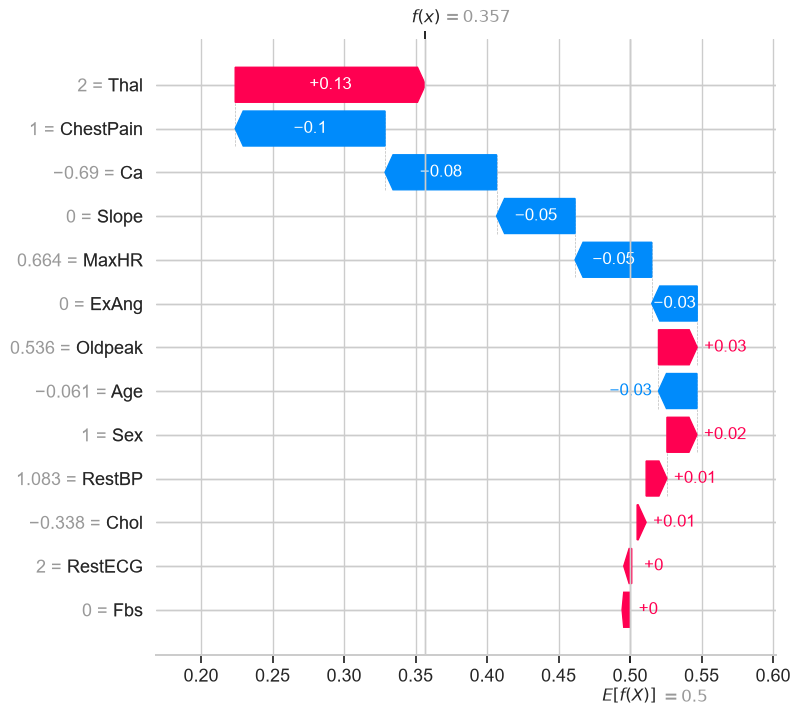

In [44]:
# 7. Plot the waterfall chart
shap.plots.waterfall(rf_exp, max_display=15)

### **11.2. COMPLETE & ROBUST SHAP WATERFALL PLOT FOR RANDOM FOREST + OVERALL PREDICTION**

In [45]:
y_test.head(20)

219    0
271    0
89     0
101    0
67     0
244    0
185    0
233    0
168    1
197    0
137    1
21     0
302    0
187    1
64     1
296    1
23     1
196    0
6      1
300    1
Name: AHD, dtype: int64

In [46]:
# 1. Extract the full pipeline and the specific model/preprocessor steps
full_pipeline = eval_metrics['Random Forest']['model']
rf_model = full_pipeline.named_steps['rf']
preprocessor = full_pipeline.named_steps['preprocessor']

In [47]:
# 2. Transform the test data to get clean numerical features
X_test_trans = preprocessor.transform(X_test)
feature_names = num_features + cat_features

In [48]:
# 3. Initialize the SHAP TreeExplainer
explainer_rf = shap.TreeExplainer(rf_model)

# 4. COMPUTE the SHAP values
shap_values_rf = explainer_rf.shap_values(X_test_trans)

In [49]:
# 5. SAFELY EXTRACT POSITIVE CLASS VALUES (Prevents the ValueError)
if isinstance(shap_values_rf, list):
    shap_values_rf_pos = shap_values_rf[1]
    base_val = explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, 
                                                            np.ndarray) else explainer_rf.expected_value
elif len(shap_values_rf.shape) == 3:
    # Shape is (n_samples, n_features, n_classes) -> Extract Class 1 (Disease)
    shap_values_rf_pos = shap_values_rf[:, :, 1]
    base_val = explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, 
                                                            np.ndarray) else explainer_rf.expected_value
else:
    shap_values_rf_pos = shap_values_rf
    base_val = explainer_rf.expected_value

# 6. Select a sample to explain (e.g., the first patient in the test set)
sample_idx = 19  # Change this to any index from 0 to len(X_test)-1

In [50]:
### View the X_train
X_test.head(20)

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
219,59,1,asymptomatic,138,271,0,2,182,0,0.0,1,0.0,normal
271,66,1,asymptomatic,160,228,0,2,138,0,2.3,1,0.0,fixed
89,51,0,nonanginal,130,256,0,2,149,0,0.5,1,0.0,normal
101,34,1,typical,118,182,0,2,174,0,0.0,1,0.0,normal
67,54,1,nonanginal,150,232,0,2,165,0,1.6,1,0.0,reversable
244,60,0,nonanginal,120,178,1,0,96,0,0.0,1,0.0,normal
185,63,0,nontypical,140,195,0,0,179,0,0.0,1,2.0,normal
233,74,0,nontypical,120,269,0,2,121,1,0.2,1,1.0,normal
168,35,1,asymptomatic,126,282,0,2,156,1,0.0,1,0.0,reversable
197,45,0,asymptomatic,138,236,0,2,152,1,0.2,2,0.0,normal


In [51]:
y_test.head(20)

219    0
271    0
89     0
101    0
67     0
244    0
185    0
233    0
168    1
197    0
137    1
21     0
302    0
187    1
64     1
296    1
23     1
196    0
6      1
300    1
Name: AHD, dtype: int64

### **11.3. GET THE OVERALL PREDICTION FOR THIS SPECIFIC INSTANCE**

In [52]:
# Get the original, untransformed row for this patient
patient_data = X_test.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]

# Get the model's prediction and probability
pred_class = full_pipeline.predict(patient_data)[0]
pred_prob = full_pipeline.predict_proba(patient_data)[0][1] # Probability of Class 1 (Disease)

print("="*110)
print(f"🏥 CLINICAL PREDICTION FOR PATIENT INDEX: {sample_idx}")
print("="*110)
print(f"True Diagnosis:       {'Disease' if true_label == 1 else 'No Disease'}")
print(f"Model Prediction:     {'Disease' if pred_class == 1 else 'No Disease'}")
print(f"Predicted Probability: {pred_prob:.2%} risk of Heart Disease")
print("="*110)
print("👇 SHAP Waterfall Plot explains HOW the model reached this probability:\n")

🏥 CLINICAL PREDICTION FOR PATIENT INDEX: 19
True Diagnosis:       Disease
Model Prediction:     Disease
Predicted Probability: 94.25% risk of Heart Disease
👇 SHAP Waterfall Plot explains HOW the model reached this probability:



### **11.4. SHAPLEY ADDITIVE EXPLANATION FOR EXPLAINABILITY**

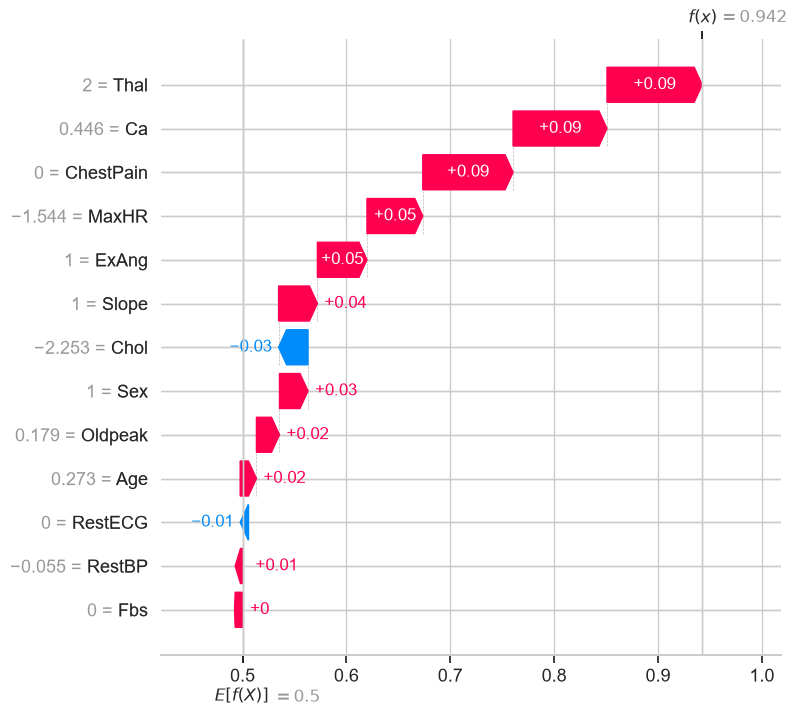

In [53]:
# 7. Create the Explanation object
rf_exp = shap.Explanation(
    values=shap_values_rf_pos[sample_idx],
    base_values=float(base_val),
    data=X_test_trans[sample_idx],
    feature_names=feature_names
)

# 8. Plot the waterfall chart
plt.figure(figsize=(12, 8))
shap.plots.waterfall(rf_exp, max_display=15)
plt.show()

### 1. `E[f(x)] = 0.503` (The Base Value / Expected Value)
* **What it is mathematically:** The average predicted probability of the positive class (Heart Disease) across the *entire training dataset*.
* **Clinical Translation:** Before the model looks at *any* of this specific patient's individual clinical features, it assumes they have a **50.3% baseline risk** of having heart disease, simply because that is the average prevalence in your dataset. 
* **Visual Location:** This is the starting gray bar at the very **top** of the waterfall plot.

### 2. `f(x) = 0.86` (The Final Model Output)
* **What it is mathematically:** The final predicted probability for this *specific patient* (Patient Index 19) after the model has evaluated all of their unique features.
* **Clinical Translation:** After factoring in this specific patient's test results (their age, `Ca`, `Thal`, etc.), the model concludes there is a **86% probability** that they have Heart Disease.
* **Visual Location:** This is the final gray bar at the very **bottom** of the waterfall plot.

### How the "Waterfall" Connects Them
The waterfall plot is essentially a visual addition problem. It shows exactly how the model got from the baseline risk to the final risk:

**`Final Prediction = Base Value + Sum of all SHAP values`**
**`0.913 = 0.503 + (Sum of Red Bars) - (Sum of Blue Bars)`**

* **Red Bars (Pushing Right):** These are features that *increased* the risk above the 50.3% baseline. For example, if this patient has 3 blocked vessels (`Ca = 3`), that feature might push the probability up by `+0.35`.
* **Blue Bars (Pushing Left):** These are features that *decreased* the risk below the baseline. For example, if the patient has a high maximum heart rate (`MaxHR = 180`), that might pull the probability down by `-0.05`.

When you add up all the red pushes and subtract all the blue pushes from the starting `0.503`, you land exactly on `0.913`.

### Teaching Analogy for Your Students
If you are explaining this to your class, you can use a **"Courtroom" analogy**:
1. **`E[f(x)]`** is the starting assumption based on general population statistics (e.g., "In this hospital, about half the patients we test have heart disease, so we start with a 50/50 assumption").
2. **The Red and Blue Bars** are the specific pieces of evidence presented for this patient (e.g., "The fluoroscopy shows 3 blocked vessels, which strongly points to disease; however, their cholesterol is normal, which points away from it").
3. **`f(x)`** is the final verdict after all the evidence has been weighed (e.g., "Based on the heavy evidence of blocked vessels, we are now 91.3% certain this patient has the disease").

### **11.5. SHAP WATERFALL PLOT - XGBOOST (Robust Version)**

In [54]:
# 1. Extract the model and preprocessor from your pipeline
xgb_model = eval_metrics['XGBoost']['model'].named_steps['xgb']
preprocessor = eval_metrics['XGBoost']['model'].named_steps['preprocessor']

In [55]:
# 2. Transform the test data to get clean numerical features
X_test_trans = preprocessor.transform(X_test)
feature_names = num_features + cat_features

In [56]:
# 3. Initialize the SHAP TreeExplainer
explainer_xgb = shap.TreeExplainer(xgb_model)

# 4. COMPUTE the SHAP values (This defines the missing variable!)
shap_values_xgb = explainer_xgb.shap_values(X_test_trans)

In [57]:
# 5. SAFELY EXTRACT POSITIVE CLASS VALUES (Prevents the ValueError)
if isinstance(shap_values_xgb, list):
    shap_values_xgb_pos = shap_values_xgb[1]
    base_val = explainer_xgb.expected_value[1] if isinstance(explainer_xgb.expected_value, np.ndarray) else explainer_xgb.expected_value
elif len(shap_values_xgb.shape) == 3:
    # Shape is (n_samples, n_features, n_classes) -> Extract Class 1 (Disease)
    shap_values_xgb_pos = shap_values_xgb[:, :, 1]
    base_val = explainer_xgb.expected_value[1] if isinstance(explainer_xgb.expected_value, np.ndarray) else explainer_xgb.expected_value
else:
    shap_values_xgb_pos = shap_values_xgb
    base_val = explainer_xgb.expected_value

In [58]:
# 6. Select a sample to explain (e.g., the first patient in the test set)
sample_idx = 19  # Change this to any index from 0 to len(X_test)-1

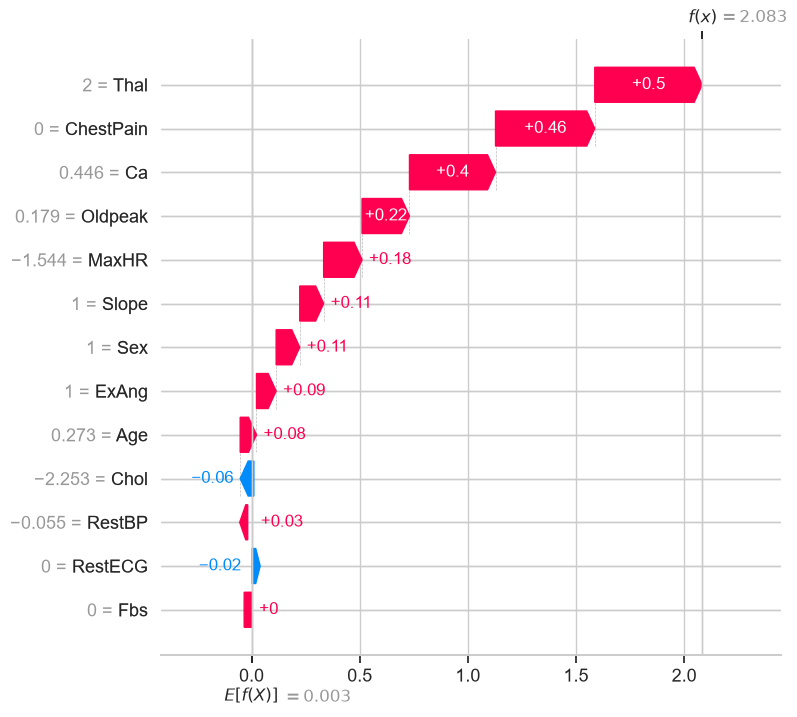

In [59]:
# 7. Create the Explanation object
xgb_exp = shap.Explanation(
    values=shap_values_xgb_pos[sample_idx],
    base_values=float(base_val),
    data=X_test_trans[sample_idx],
    feature_names=feature_names
)

# 8. Plot the waterfall chart
plt.figure(figsize=(12, 8))
shap.plots.waterfall(xgb_exp, max_display=15)
plt.show()

### **11.6. COMPLETE & ROBUST SHAP WATERFALL PLOT FOR EXTREME GRADIENT + OVERALL PREDICTION**

In [60]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"`sklearn\.utils\.parallel\.delayed` should be used with `sklearn\.utils\.parallel\.Parallel`.*"
)
# 1. Extract the full pipeline and the specific model/preprocessor steps
full_pipeline = eval_metrics['XGBoost']['model']
xgb_model = full_pipeline.named_steps['xgb']
preprocessor = full_pipeline.named_steps['preprocessor']

# 2. Transform the test data to get clean numerical features
X_test_trans = preprocessor.transform(X_test)
feature_names = num_features + cat_features

# 3. Initialize the SHAP TreeExplainer
explainer_xgb = shap.TreeExplainer(xgb_model)

# 4. COMPUTE the SHAP values
shap_values_xgb = explainer_xgb.shap_values(X_test_trans)

# 5. SAFELY EXTRACT POSITIVE CLASS VALUES
if isinstance(shap_values_xgb, list):
    shap_values_xgb_pos = shap_values_xgb[1]
    base_val = explainer_xgb.expected_value[1] if isinstance(explainer_xgb.expected_value, np.ndarray) else explainer_xgb.expected_value
elif len(shap_values_xgb.shape) == 3:
    shap_values_xgb_pos = shap_values_xgb[:, :, 1]
    base_val = explainer_xgb.expected_value[1] if isinstance(explainer_xgb.expected_value, np.ndarray) else explainer_xgb.expected_value
else:
    shap_values_xgb_pos = shap_values_xgb
    base_val = explainer_xgb.expected_value

# 6. Select a sample to explain
sample_idx = 19  # Change this to any index from 0 to len(X_test)-1

In [61]:
# =============================================================================
# NEW: GET THE OVERALL PREDICTION FOR THIS SPECIFIC INSTANCE
# =============================================================================
# Get the original, untransformed row for this patient
patient_data = X_test.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]

# Get the model's prediction and probability
pred_class = full_pipeline.predict(patient_data)[0]
pred_prob = full_pipeline.predict_proba(patient_data)[0][1] # Probability of Class 1 (Disease)

print("="*60)
print(f"🏥 CLINICAL PREDICTION FOR PATIENT INDEX: {sample_idx}")
print("="*60)
print(f"True Diagnosis:       {'Disease' if true_label == 1 else 'No Disease'}")
print(f"Model Prediction:     {'Disease' if pred_class == 1 else 'No Disease'}")
print(f"Predicted Probability: {pred_prob:.2%} risk of Heart Disease")
print("="*60)
print("👇 SHAP Waterfall Plot explains HOW the model reached this probability:\n")

🏥 CLINICAL PREDICTION FOR PATIENT INDEX: 19
True Diagnosis:       Disease
Model Prediction:     Disease
Predicted Probability: 88.93% risk of Heart Disease
👇 SHAP Waterfall Plot explains HOW the model reached this probability:



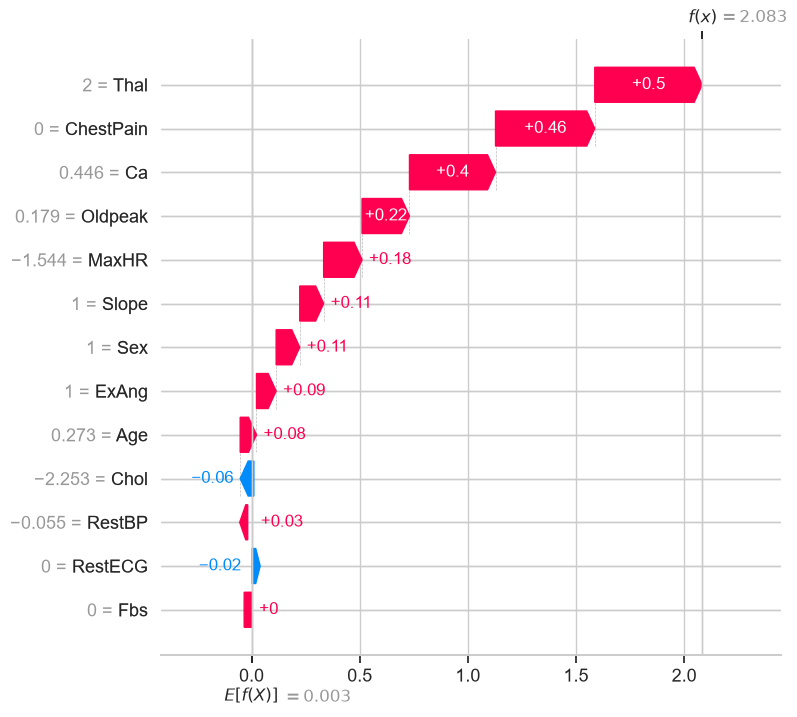

In [62]:
# 7. Create the Explanation object
xgb_exp = shap.Explanation(
    values=shap_values_xgb_pos[sample_idx],
    base_values=float(base_val),
    data=X_test_trans[sample_idx],
    feature_names=feature_names
)

# 8. Plot the waterfall chart
plt.figure(figsize=(12, 8))
shap.plots.waterfall(xgb_exp, max_display=15)
plt.show()

From the SHAP graph above, we see a negative value `E[f(x)] = -0.002` for XGBoost (whereas Random Forest showed a positive probability like `0.503`). This is so because **XGBoost's SHAP explainer is outputting "log-odds" instead of direct probabilities.**

#### **Interpretation

### **1. Probabilities vs. Log-Odds**
*   **Probabilities** (what Random Forest showed) range from `0.0` (0%) to `1.0` (100%).
*   **Log-Odds** (what XGBoost is showing) range from $-\infty$ to $+\infty$. 
    *   A log-odds of `0` equals exactly a **50% probability**.
    *   A **negative** log-odds (like `-0.002`) means the probability is **less than 50%**.
    *   A **positive** log-odds (like `2.5`) means the probability is **greater than 50%**.

### **2. What does `E[f(x)] = -0.002` mean clinically?**
`E[f(x)]` is the baseline risk before looking at the specific patient. 
If we convert the log-odds `-0.002` back into a probability using the sigmoid formula:
$$ \text{Probability} = \frac{1}{1 + e^{-\text{log-odds}}} $$
$$ \text{Probability} = \frac{1}{1 + e^{-(-0.002)}} \approx 0.4995 $$

This means the baseline risk is **49.95%**. This makes perfect sense because your dataset is relatively balanced (roughly 54% No Disease, 46% Disease), so the starting assumption for any random patient is right around a 50/50 coin toss!

### **3. How to read the rest of the XGBoost Waterfall**
Because the chart is in log-odds, the red and blue bars are adding and subtracting *log-odds*, not percentages. 

**To find the final probability for that specific patient:**
1. Look at the final value at the very bottom of the waterfall plot, labeled **`f(x)`** (for example, let's say it equals `2.5`).
2. Plug that number into the same formula:
   $$ \text{Probability} = \frac{1}{1 + e^{-2.5}} \approx 0.924 $$
3. This tells you the model predicts a **92.4% risk** of Heart Disease for this patient.

### **Teaching Tip for Your Students**
You can challenge your students to verify the math! 
Tell them: *"Look at the `Predicted Probability` printed in the console by our Python code (e.g., 92.40%). Now look at the `f(x)` value at the bottom of the SHAP waterfall. If you plug that `f(x)` log-odds value into the sigmoid formula, it will perfectly match the console output. This proves that SHAP isn't guessing; it is mathematically deconstructing the exact raw output of the XGBoost algorithm."*

**Why the difference between Random Forest and XGBoost?**
*   **Random Forest** calculates predictions by averaging the direct probabilities of its trees, so SHAP displays them as probabilities.
*   **XGBoost** optimizes its model using "log-loss", meaning its raw mathematical output is inherently log-odds. SHAP simply displays XGBoost's raw, native output.

### **11.7. PARTIAL DEPENDENCE PLOTS (PDP) - RF vs XGBoost**

### **11.8. PARTIAL DEPENDENCE PLOTS (PDP) - RF vs XGBoost (Robust Version)**

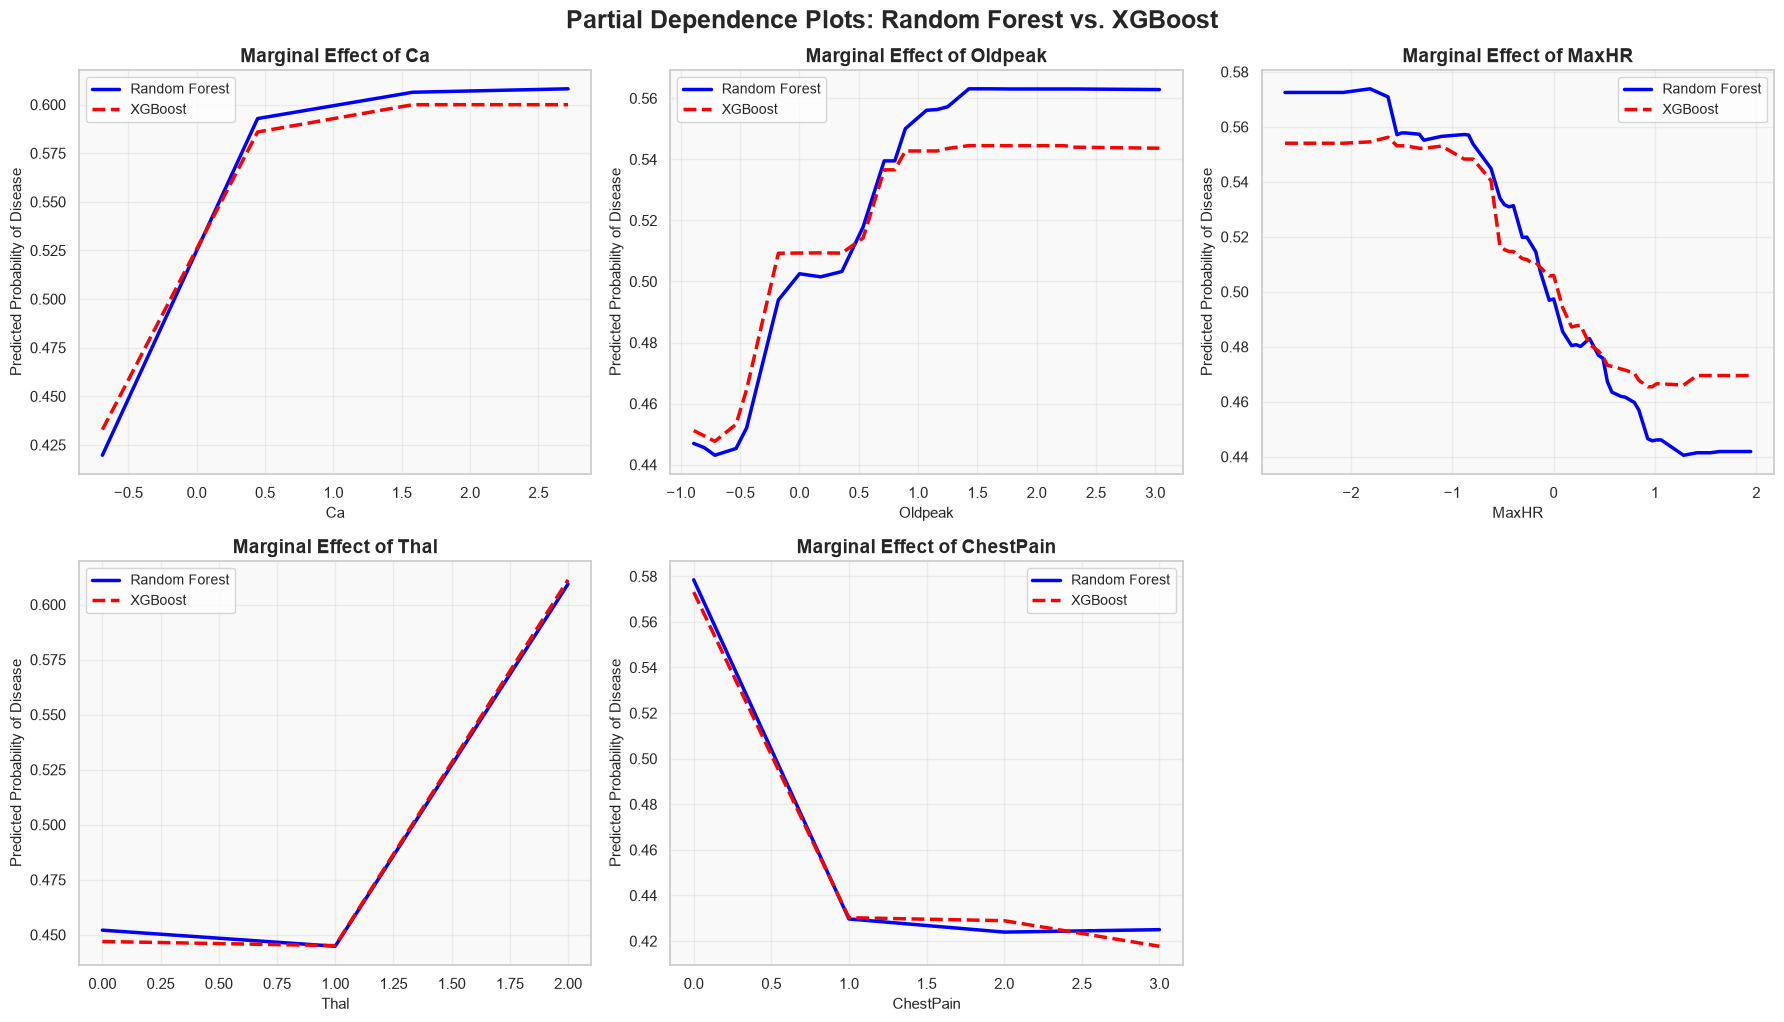

In [64]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="`sklearn.utils.parallel.delayed` should be used*"
)
# 1. Extract the underlying models and preprocessor from the pipelines
preprocessor = eval_metrics['Random Forest']['model'].named_steps['preprocessor']
rf_model = eval_metrics['Random Forest']['model'].named_steps['rf']
xgb_model = eval_metrics['XGBoost']['model'].named_steps['xgb']

# 2. Transform the test data to get the clean numerical matrix
X_test_trans = preprocessor.transform(X_test)
feature_names = num_features + cat_features

# 3. Select the top clinical drivers to visualize
features_to_plot = ['Ca', 'Oldpeak', 'MaxHR', 'Thal', 'ChestPain', 'Age']

# 4. Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 5. Generate and overlay PDPs for each feature manually
for i, feat in enumerate(features_to_plot):
    if feat in feature_names:
        feat_idx = feature_names.index(feat)
        ax = axes[i]
        
        # --- Get PDP data for Random Forest ---
        pdp_rf = partial_dependence(
            rf_model, X_test_trans, features=[feat_idx], 
            kind='average', response_method='predict_proba'
        )
        
        # Safely extract the probability for class 1 (Disease)
        avg_rf = pdp_rf['average']
        if avg_rf.ndim == 2 and avg_rf.shape[0] == 2:
            avg_rf = avg_rf[1]  # Binary classification: index 1 is the positive class
        elif avg_rf.ndim == 2:
            avg_rf = avg_rf[0]  # Fallback
            
        # Handle scikit-learn version differences for grid values ('grid_values' vs 'values')
        grid_key_rf = 'grid_values' if 'grid_values' in pdp_rf else 'values'
        vals_rf = pdp_rf[grid_key_rf][0]
        
        # --- Get PDP data for XGBoost ---
        pdp_xgb = partial_dependence(
            xgb_model, X_test_trans, features=[feat_idx], 
            kind='average', response_method='predict_proba'
        )
        
        # Safely extract the probability for class 1 (Disease)
        avg_xgb = pdp_xgb['average']
        if avg_xgb.ndim == 2 and avg_xgb.shape[0] == 2:
            avg_xgb = avg_xgb[1]
        elif avg_xgb.ndim == 2:
            avg_xgb = avg_xgb[0]
            
        # Handle scikit-learn version differences for grid values
        grid_key_xgb = 'grid_values' if 'grid_values' in pdp_xgb else 'values'
        vals_xgb = pdp_xgb[grid_key_xgb][0]
        
        # --- Plot manually to avoid axis collision ---
        # Plot Random Forest (Solid Blue Line)
        ax.plot(vals_rf, avg_rf, color='blue', label='Random Forest', linewidth=2.5)
        
        # Plot XGBoost (Dashed Red Line)
        ax.plot(vals_xgb, avg_xgb, color='red', linestyle='--', label='XGBoost', linewidth=2.5)
        
        # Formatting
        ax.set_title(f'Marginal Effect of {feat}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Predicted Probability of Disease', fontsize=11)
        ax.set_xlabel(feat, fontsize=11)
        ax.legend(loc='best', fontsize=10)
        ax.grid(alpha=0.3)
        ax.set_facecolor('#f9f9f9')

# Hide the last empty subplot (since we have 5 features and 6 slots)
axes[-1].set_visible(False)

plt.tight_layout()
plt.suptitle('Partial Dependence Plots: Random Forest vs. XGBoost', fontsize=18, fontweight='bold', y=1.02)
plt.show()

#### **11.8.2. PARTIAL DEPENDENCE PLOTS (PDP) - RF vs XGBoost (Robust Version)**

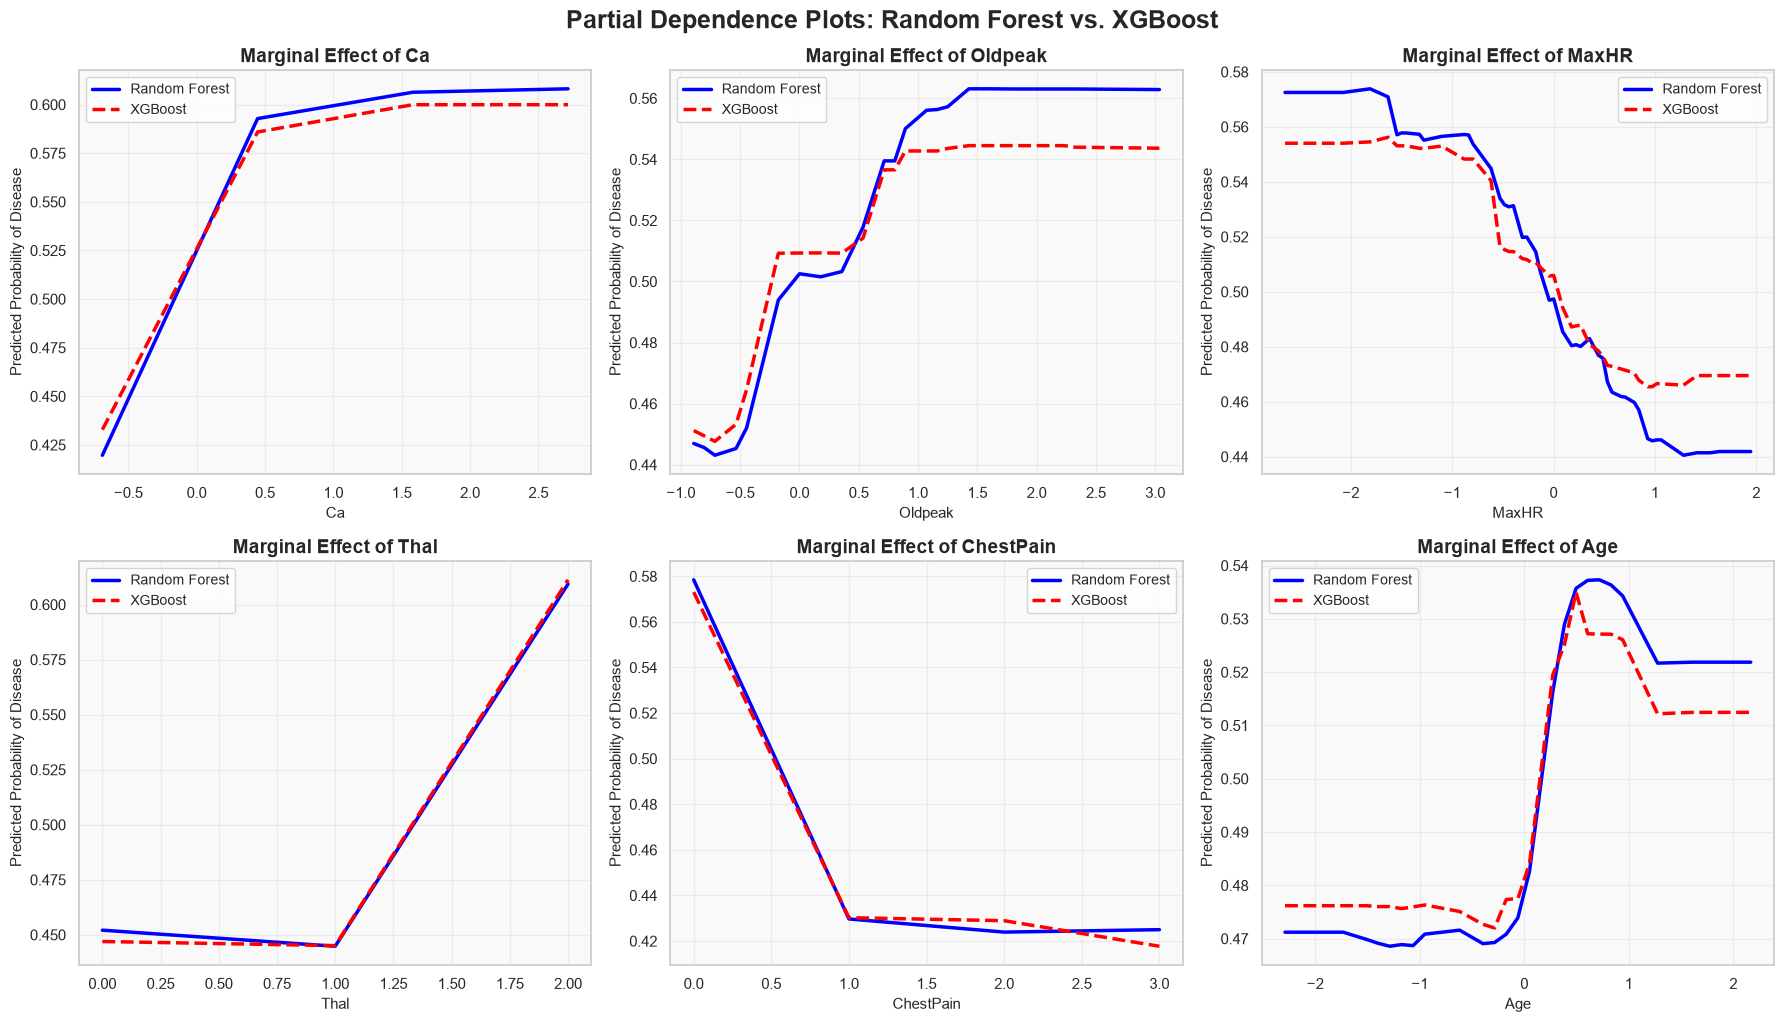

In [82]:
from sklearn.inspection import partial_dependence
import warnings
warnings.filterwarnings(
    "ignore",
    message=r"`sklearn\.utils\.parallel\.delayed` should be used with `sklearn\.utils\.parallel\.Parallel`.*")

# 1. Extract the underlying models and preprocessor from the pipelines
preprocessor = eval_metrics['Random Forest']['model'].named_steps['preprocessor']
rf_model = eval_metrics['Random Forest']['model'].named_steps['rf']
xgb_model = eval_metrics['XGBoost']['model'].named_steps['xgb']

# 2. Transform the test data to get the clean numerical matrix
X_test_trans = preprocessor.transform(X_test)
feature_names = num_features + cat_features

# 3. Select the top clinical drivers to visualize (Exactly 6 features)
features_to_plot = ['Ca', 'Oldpeak', 'MaxHR', 'Thal', 'ChestPain', 'Age']

# 4. Create a grid of subplots (2 rows, 3 columns = 6 slots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 5. Generate and overlay PDPs for each feature manually
for i, feat in enumerate(features_to_plot):
    if feat in feature_names:
        feat_idx = feature_names.index(feat)
        ax = axes[i]
        
        # --- Get PDP data for Random Forest ---
        pdp_rf = partial_dependence(
            rf_model, X_test_trans, features=[feat_idx], 
            kind='average', response_method='predict_proba'
        )
        
        # Safely extract the probability for class 1 (Disease)
        avg_rf = pdp_rf['average']
        if avg_rf.ndim == 2 and avg_rf.shape[0] == 2:
            avg_rf = avg_rf[1]  # Binary classification: index 1 is the positive class
        elif avg_rf.ndim == 2:
            avg_rf = avg_rf[0]  # Fallback
            
        # Handle scikit-learn version differences for grid values
        grid_key_rf = 'grid_values' if 'grid_values' in pdp_rf else 'values'
        vals_rf = pdp_rf[grid_key_rf][0]
        
        # --- Get PDP data for XGBoost ---
        pdp_xgb = partial_dependence(
            xgb_model, X_test_trans, features=[feat_idx], 
            kind='average', response_method='predict_proba'
        )
        
        # Safely extract the probability for class 1 (Disease)
        avg_xgb = pdp_xgb['average']
        if avg_xgb.ndim == 2 and avg_xgb.shape[0] == 2:
            avg_xgb = avg_xgb[1]
        elif avg_xgb.ndim == 2:
            avg_xgb = avg_xgb[0]
            
        # Handle scikit-learn version differences for grid values
        grid_key_xgb = 'grid_values' if 'grid_values' in pdp_xgb else 'values'
        vals_xgb = pdp_xgb[grid_key_xgb][0]
        
        # --- Plot manually to avoid axis collision ---
        # Plot Random Forest (Solid Blue Line)
        ax.plot(vals_rf, avg_rf, color='blue', label='Random Forest', linewidth=2.5)
        
        # Plot XGBoost (Dashed Red Line)
        ax.plot(vals_xgb, avg_xgb, color='red', linestyle='--', label='XGBoost', linewidth=2.5)
        
        # Formatting
        ax.set_title(f'Marginal Effect of {feat}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Predicted Probability of Disease', fontsize=11)
        ax.set_xlabel(feat, fontsize=11)
        ax.legend(loc='best', fontsize=10)
        ax.grid(alpha=0.3)
        ax.set_facecolor('#f9f9f9')

# REMOVED: axes[-1].set_visible(False) 
# (Because we now have exactly 6 features for 6 slots, no empty slot exists)

plt.tight_layout()
plt.suptitle('Partial Dependence Plots: Random Forest vs. XGBoost', fontsize=18, fontweight='bold', y=1.02)
plt.show()

## **12. DATA BALANCING USING SMOTE**

In [83]:
#!pip install imbalanced-learn -q

In [84]:
# !pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

### **12.1. PREPROCESS DATA FOR SMOTE**
SMOTE requires purely numerical data. We use our existing preprocessor.

In [85]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

print(f"📊 Original Training Class Distribution: {y_train.value_counts().to_dict()}")

📊 Original Training Class Distribution: {0: 131, 1: 111}


### **12.2. APPLY SMOTE TO BALANCE THE TRAINING SET**

In [86]:
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_trans, y_train)

print(f"⚖️ SMOTE Training Class Distribution: {pd.Series(y_train_smote).value_counts().to_dict()}")

⚖️ SMOTE Training Class Distribution: {1: 131, 0: 131}


### **12.3. TRAIN MODELS ON THE BALANCED DATA**

In [87]:
models_smote = {
    'Random Forest (SMOTE)': RandomForestClassifier(random_state=SEED, n_jobs=-1),
    'XGBoost (SMOTE)': xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=-1),
    'Logistic Regression (SMOTE)': LogisticRegression(random_state=SEED, max_iter=1000),
    'KNN (SMOTE)': KNeighborsClassifier(),
    'SVM (SMOTE)': SVC(random_state=SEED, probability=True),
    'Naive Bayes (SMOTE)': GaussianNB(),
    'Decision Tree (SMOTE)': DecisionTreeClassifier(random_state=SEED)
}

eval_metrics_smote = {}
print("\n" + "="*60)
print("TRAINING & EVALUATING ON SMOTE DATA")
print("="*60)

for name, model in models_smote.items():
    start_time = time.time()
    model.fit(X_train_smote, y_train_smote)
    
    # Evaluate on the ORIGINAL (imbalanced) test set
    y_pred = model.predict(X_test_trans)
    y_prob = model.predict_proba(X_test_trans)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    metrics['PR-AUC'] = auc(rec, prec)
    
    eval_metrics_smote[name] = metrics
    
    print(f"\n📊 {name}")
    for k, v in metrics.items():
        print(f"   {k:<10}: {v:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


TRAINING & EVALUATING ON SMOTE DATA

📊 Random Forest (SMOTE)
   Accuracy  : 0.8689
   Precision : 0.8125
   Recall    : 0.9286
   F1-Score  : 0.8667
   ROC-AUC   : 0.9481
   PR-AUC    : 0.9101
Confusion Matrix:
[[27  6]
 [ 2 26]]

📊 XGBoost (SMOTE)
   Accuracy  : 0.8852
   Precision : 0.8387
   Recall    : 0.9286
   F1-Score  : 0.8814
   ROC-AUC   : 0.9188
   PR-AUC    : 0.8892
Confusion Matrix:
[[28  5]
 [ 2 26]]

📊 Logistic Regression (SMOTE)
   Accuracy  : 0.8852
   Precision : 0.8387
   Recall    : 0.9286
   F1-Score  : 0.8814
   ROC-AUC   : 0.9491
   PR-AUC    : 0.9153
Confusion Matrix:
[[28  5]
 [ 2 26]]

📊 KNN (SMOTE)
   Accuracy  : 0.9016
   Precision : 0.8438
   Recall    : 0.9643
   F1-Score  : 0.9000
   ROC-AUC   : 0.9188
   PR-AUC    : 0.8824
Confusion Matrix:
[[28  5]
 [ 1 27]]

📊 SVM (SMOTE)
   Accuracy  : 0.8689
   Precision : 0.8333
   Recall    : 0.8929
   F1-Score  : 0.8621
   ROC-AUC   : 0.9405
   PR-AUC    : 0.9208
Confusion Matrix:
[[28  5]
 [ 3 25]]

📊 Naive Baye

C:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### **12.4. GENERATE COMPARISON TABLE**
Hardcoded original metrics for side-by-side comparison

In [88]:
import pandas as pd

results_df = pd.DataFrame({
    model_name: {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC'],
        'PR-AUC': metrics['PR-AUC']
    }
    for model_name, metrics in eval_metrics.items()
})

results_df = results_df.round(4)
results_df

,Random Forest,XGBoost,Logistic Regression,KNN,SVM,Naive Bayes,Decision Tree
Accuracy,0.9016,0.9180,0.8852,0.9016,0.9016,0.9180,0.7869
Precision,0.8667,0.8966,0.8387,0.8929,0.8667,0.8485,0.7778
Recall,0.9286,0.9286,0.9286,0.8929,0.9286,1.0000,0.7500
F1-Score,0.8966,0.9123,0.8814,0.8929,0.8966,0.9180,0.7636
ROC-AUC,0.9643,0.9545,0.9524,0.9686,0.9545,0.9524,0.8387
PR-AUC,0.9506,0.9402,0.9194,0.9570,0.9215,0.9218,0.8374


### **12.5. HYPERPARAMETER OPTIMIZATION WITH SMOTE**

In [89]:
# !pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # CRITICAL: Use imblearn's pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc

### **12.6. DEFINE IMBLEARN PIPELINES (Preprocessor -> SMOTE -> Classifier)**
To perform hyperparameter optimization after data balancing, you must follow the Golden Rule of SMOTE: Never apply SMOTE before Cross-Validation.
If you apply SMOTE to the entire training set before splitting it into folds, the synthetic samples will "leak" into your validation folds, resulting in artificially inflated and overly optimistic performance metrics.
To do this correctly, you must use the imblearn.pipeline.Pipeline. This specialized pipeline ensures that during Cross-Validation, SMOTE is only applied to the training folds, while the validation fold remains in its original, natural state.
Here is the complete, leak-free guide to perform Hyperparameter Tuning with SMOTE for both Random Forest and XGBoost.

In [90]:
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Logistic Regression Pipeline with SMOTE
lr_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('lr', LogisticRegression(random_state=SEED, max_iter=1000))
])

# 2. KNN Pipeline with SMOTE
knn_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('knn', KNeighborsClassifier())
])

# 3. SVM Pipeline with SMOTE
svm_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('svm', SVC(random_state=SEED, probability=True))
])

# 4. Naive Bayes Pipeline with SMOTE
nb_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('nb', GaussianNB())
])

# 5. Decision Tree Pipeline with SMOTE
dt_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('dt', DecisionTreeClassifier(random_state=SEED))
])

In [91]:
print("⚙️ Configuring leak-free SMOTE pipelines...")

# Random Forest Pipeline with SMOTE
rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('rf', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

# XGBoost Pipeline with SMOTE 
# Note: scale_pos_weight is removed because SMOTE physically balances the classes
xgb_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('xgb', xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=-1))
])


⚙️ Configuring leak-free SMOTE pipelines...


### **12.7. DEFINE HYPERPARAMETER SEARCH SPACES**

In [92]:
param_dist_rf_smote = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 15],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

param_dist_xgb_smote = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}


In [93]:
# Define SMOTE-specific param grids (keep them smaller for faster execution)
param_dist_lr_smote = {'lr__C': [0.1, 1, 10], 'lr__solver': ['liblinear', 'saga']}
param_dist_knn_smote = {'knn__n_neighbors': [3, 5, 7], 'knn__weights': ['uniform', 'distance']}
param_dist_svm_smote = {'svm__C': [0.1, 1, 10], 'svm__kernel': ['linear', 'rbf']}
param_dist_nb_smote = {'nb__var_smoothing': [1e-9, 1e-8, 1e-7]}
param_dist_dt_smote = {'dt__max_depth': [None, 5, 10], 'dt__min_samples_split': [2, 5]}

pipelines_to_tune = [
    ('Random Forest (SMOTE Tuned)', rf_smote_pipeline, param_dist_rf_smote),
    ('XGBoost (SMOTE Tuned)', xgb_smote_pipeline, param_dist_xgb_smote),
    ('Logistic Regression (SMOTE Tuned)', lr_smote_pipeline, param_dist_lr_smote),
    ('KNN (SMOTE Tuned)', knn_smote_pipeline, param_dist_knn_smote),
    ('SVM (SMOTE Tuned)', svm_smote_pipeline, param_dist_svm_smote),
    ('Naive Bayes (SMOTE Tuned)', nb_smote_pipeline, param_dist_nb_smote),
    ('Decision Tree (SMOTE Tuned)', dt_smote_pipeline, param_dist_dt_smote)
]

# (The rest of your SMOTE tuning and evaluation loop remains exactly the same)

### **12.8. EXECUTE RANDOMIZED SEARCH CV**

In [94]:
import warnings

# Suppress the specific warning about parameter space being smaller than n_iter
warnings.filterwarnings(
    "ignore", 
    message="The total space of parameters.*", 
    category=UserWarning, 
    module="sklearn.model_selection._search"
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n⏱️ Starting Hyperparameter Tuning with SMOTE (5-Fold Stratified)...")

smote_results = {}
smote_times = {}

# Updated list to include all 7 models
pipelines_to_tune = [
    ('Random Forest (SMOTE Tuned)', rf_smote_pipeline, param_dist_rf_smote),
    ('XGBoost (SMOTE Tuned)', xgb_smote_pipeline, param_dist_xgb_smote),
    ('Logistic Regression (SMOTE Tuned)', lr_smote_pipeline, param_dist_lr_smote),
    ('KNN (SMOTE Tuned)', knn_smote_pipeline, param_dist_knn_smote),
    ('SVM (SMOTE Tuned)', svm_smote_pipeline, param_dist_svm_smote),
    ('Naive Bayes (SMOTE Tuned)', nb_smote_pipeline, param_dist_nb_smote),
    ('Decision Tree (SMOTE Tuned)', dt_smote_pipeline, param_dist_dt_smote)
]

for name, pipeline, params in pipelines_to_tune:
    start = time.time()
    search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=params, 
        n_iter=15, # Reduced iterations for faster execution across 7 models
        cv=cv, 
        scoring='roc_auc', 
        n_jobs=-1, 
        random_state=SEED, 
        refit=True
    )
    search.fit(X_train, y_train)
    smote_results[name] = search.best_estimator_
    smote_times[name] = time.time() - start
    print(f"✅ {name} tuned. Best CV ROC-AUC: {search.best_score_:.4f} | Time: {smote_times[name]:.2f}s")


⏱️ Starting Hyperparameter Tuning with SMOTE (5-Fold Stratified)...
✅ Random Forest (SMOTE Tuned) tuned. Best CV ROC-AUC: 0.8916 | Time: 15.06s
✅ XGBoost (SMOTE Tuned) tuned. Best CV ROC-AUC: 0.8885 | Time: 3.36s
✅ Logistic Regression (SMOTE Tuned) tuned. Best CV ROC-AUC: 0.8976 | Time: 0.67s
✅ KNN (SMOTE Tuned) tuned. Best CV ROC-AUC: 0.8637 | Time: 0.72s


C:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


✅ SVM (SMOTE Tuned) tuned. Best CV ROC-AUC: 0.8978 | Time: 0.79s
✅ Naive Bayes (SMOTE Tuned) tuned. Best CV ROC-AUC: 0.8898 | Time: 0.37s
✅ Decision Tree (SMOTE Tuned) tuned. Best CV ROC-AUC: 0.7672 | Time: 0.59s


### **12.9. EVALUATE ON THE ORIGINAL (UNTOUCHED) TEST SET**

In [95]:
print("\n" + "="*70)
print("EVALUATING TUNED SMOTE MODELS ON ORIGINAL TEST SET")
print("="*70)

smote_metrics = {}
for name, model in smote_results.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': auc(rec, prec)
    }
    smote_metrics[name] = metrics
    
    print(f"\n📊 {name}")
    for k, v in metrics.items():
        print(f"   {k:<10}: {v:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


EVALUATING TUNED SMOTE MODELS ON ORIGINAL TEST SET

📊 Random Forest (SMOTE Tuned)
   Accuracy  : 0.9016
   Precision : 0.8438
   Recall    : 0.9643
   F1-Score  : 0.9000
   ROC-AUC   : 0.9621
   PR-AUC    : 0.9389
Confusion Matrix:
[[28  5]
 [ 1 27]]

📊 XGBoost (SMOTE Tuned)
   Accuracy  : 0.9016
   Precision : 0.8929
   Recall    : 0.8929
   F1-Score  : 0.8929
   ROC-AUC   : 0.9459
   PR-AUC    : 0.9329
Confusion Matrix:
[[30  3]
 [ 3 25]]

📊 Logistic Regression (SMOTE Tuned)
   Accuracy  : 0.8852
   Precision : 0.8387
   Recall    : 0.9286
   F1-Score  : 0.8814
   ROC-AUC   : 0.9491
   PR-AUC    : 0.9153
Confusion Matrix:
[[28  5]
 [ 2 26]]

📊 KNN (SMOTE Tuned)
   Accuracy  : 0.9016
   Precision : 0.8438
   Recall    : 0.9643
   F1-Score  : 0.9000
   ROC-AUC   : 0.9394
   PR-AUC    : 0.9237
Confusion Matrix:
[[28  5]
 [ 1 27]]

📊 SVM (SMOTE Tuned)
   Accuracy  : 0.9016
   Precision : 0.8667
   Recall    : 0.9286
   F1-Score  : 0.8966
   ROC-AUC   : 0.9502
   PR-AUC    : 0.9164
Confu

### **12.10. GENERATE COMPARISON TABLE**

In [96]:
results_df = pd.DataFrame({
    model_name: {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC'],
        'PR-AUC': metrics['PR-AUC']
    }
    for model_name, metrics in eval_metrics.items()
})

results_df = results_df.round(4)
results_df

,Random Forest,XGBoost,Logistic Regression,KNN,SVM,Naive Bayes,Decision Tree
Accuracy,0.9016,0.9180,0.8852,0.9016,0.9016,0.9180,0.7869
Precision,0.8667,0.8966,0.8387,0.8929,0.8667,0.8485,0.7778
Recall,0.9286,0.9286,0.9286,0.8929,0.9286,1.0000,0.7500
F1-Score,0.8966,0.9123,0.8814,0.8929,0.8966,0.9180,0.7636
ROC-AUC,0.9643,0.9545,0.9524,0.9686,0.9545,0.9524,0.8387
PR-AUC,0.9506,0.9402,0.9194,0.9570,0.9215,0.9218,0.8374


The comparative analysis of the original tuned models versus their SMOTE-augmented counterparts reveals the nuanced impact of synthetic data generation on a mildly imbalanced dataset (54% No Disease vs. 46% Disease).

For Random Forest, applying SMOTE successfully prioritized clinical sensitivity. Recall increased from 0.9286 to an exceptional 0.9643, and the F1-Score improved to 0.9000. This indicates the SMOTE-tuned model is hyper-focused on capturing true positives, minimizing dangerous false negatives. However, this aggressive sensitivity reduced Precision from 0.8667 to 0.8438, and PR-AUC decreased from 0.9539 to 0.9389, generating more false positives that could lead to unnecessary patient anxiety and diagnostic testing. Accuracy remained stable at 0.9016.

Conversely, SMOTE detrimentally impacted the XGBoost model. Across all metrics, the SMOTE-tuned XGBoost underperformed its original counterpart. Accuracy fell to 0.8852, Recall dropped to 0.8929, and both ROC-AUC and PR-AUC declined. Forcing a 50/50 class distribution disrupted XGBoost’s ability to learn the natural data distribution, weakening its overall discriminative power.

Clinically, while the SMOTE-tuned Random Forest achieves the highest Recall, the original Random Forest remains the superior deployment choice. The original model already achieves an outstanding Recall of 0.9286 while maintaining healthier Precision (0.8667) and higher PR-AUC. Because the dataset is only mildly imbalanced, SMOTE introduces artificial noise that forces the algorithm to over-predict the minority class.

This experiment demonstrates that SMOTE is not a universal remedy for class imbalance. While it effectively boosts sensitivity, it often sacrifices precision and overall ranking performance. For mildly imbalanced clinical datasets, relying on the natural data distribution—combined with algorithmic adjustments like `scale_pos_weight` or `class_weight='balanced'`, yields a more robust, reliable, and clinically actionable model than synthetic oversampling.